# 🎓 Career Satisfaction 5-Class Supervised Classification & ML Benchmarking
### Project: Graduate Career & Industry Feedback Survey Analysis
**Dataset:** `dataset.xlsx` ($N = 504$ raw responses, 26 survey columns)  
**Task:** Supervised Multi-Class Classification of **Graduate Career Satisfaction** using the original **5 Satisfaction Levels (1–5)**.

---

## 📋 Evaluation Setup & Core Machine Learning Workflow:
1. **Environment Setup & Library Imports**
2. **Data Loading & Dataset Exploration (`dataset.xlsx`)**
3. **Target Variable Definition & 5-Class Satisfaction Labels**
4. **Exploratory Impact Analysis of Column 19 (`Domain_Shift_Intent`)**
5. **Step-by-Step Feature Preprocessing & Engineering:**
   - *5.1 Column Exclusion Audit & Scientific Justifications*
   - *5.2 Temporal & Seniority Feature Engineering (`Years_Since_Grad`)*
   - *5.3 Career Domain Pivots (`Domain_Switched`)*
   - *5.4 Future Domain Shift Intent (`Domain_Shift_Intent` - Col 19)*
   - *5.5 Distinct Academic Helpfulness Dimensions (Cols 4–9)*
   - *5.6 Technical, Competitive & Extracurricular Feature Mappings (Cols 10–15)*
   - *5.7 AI Perceptions & Usage Readiness (Cols 21–23)*
   - *5.8 Final Feature Matrix Construction & Null Verification*
6. **Stratified Train-Test Split (80% Train / 20% Holdout Test)**
7. **Pipeline Feature Scaling & One-Hot Encoding (`ColumnTransformer`)**
8. **9 Core Machine Learning Classifiers with Explicit Hyperparameters:**
   1. **Decision Tree (CART / J48)**
   2. **Gradient Boosting Classifier (GBDT)**
   3. **$k$-Nearest Neighbors ($k=5$)**
   4. **Logistic Regression (Balanced L2)**
   5. **Multi-Layer Perceptron (MLP Neural Network)**
   6. **Naive Bayes (Gaussian)**
   7. **Random Forest Classifier**
   8. **Ridge Classifier**
   9. **Support Vector Machine (SVM RBF)**
9. **5-Fold Stratified Cross-Validation & 80:20 Holdout Test Evaluation**
10. **Comparative Performance Visualizations**
11. **$3 \times 3$ Confusion Matrix Analysis**
12. **Multi-Class One-vs-Rest (OvR) ROC Curves & Macro AUC Diagnostics**
13. **Feature Importance Analysis (Random Forest Gini Importance)**
14. **Clean Dataset Export for WEKA Replication (`.csv` and `.arff`)**

## 1. Environment Setup & Library Imports
We import core scientific and machine learning libraries across the 9 designated classification algorithms.

In [1]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn Model Selection, Preprocessing & Evaluation Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)

# 9 Requested Supervised Machine Learning Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print("All required 9 machine learning algorithms and evaluation modules successfully imported.")

All required 9 machine learning algorithms and evaluation modules successfully imported.


## 2. Data Loading & Dataset Overview
We load the raw survey dataset `dataset.xlsx` ($N = 504$ respondents across 26 survey columns) and inspect data dimensions.

In [3]:
# Load survey dataset
file_path = 'dataset.xlsx'
raw_df = pd.read_excel(file_path)

# Normalize survey column names while preserving the original column order
normalized_columns = [
    'Timestamp', 'University_Name', 'Graduation_Year', 'Professional_Status',
    'University_Studies_Effect', 'Help_Lecture', 'Help_Lab',
    'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network',
    'Club_Participation', 'Internship_Part_Time_Freelance',
    'Software_Projects_Built', 'GitHub_Maintenance',
    'Programming_Contest_Involvement', 'Problem_Solving_Ability',
    'First_Career_Domain', 'Current_Career_Domain', 'Career_Satisfaction',
    'Future_Domain_Shift', 'Planned_Domain', 'AI_Usage_Frequency',
    'AI_Concerns_Opinion', 'AI_Programming_Reliance',
    'Academic_Improvement_Suggestions', 'CoCurricular_Job_Suggestions'
]
if len(raw_df.columns) == len(normalized_columns):
    raw_df.columns = normalized_columns
else:
    raise ValueError(f'Expected {len(normalized_columns)} columns, found {len(raw_df.columns)}')

# Apply university-name normalization once for the complete dataset
university_mapping = {
    'Daffodil International University': 'DIU',
    'DIU': 'DIU',
    'Green University': 'Green University of Bangladesh',
    'Green University of Bangladesh': 'Green University of Bangladesh',
    'BM COllage': 'BM College',
    'College of Business Science and technology (CBST)': 'CBST'
}
raw_df['University_Name'] = (
    raw_df['University_Name'].fillna('Not Specified')
    .astype(str).str.strip().replace(university_mapping)
)
print(f"Loaded Raw Dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")

# Preview raw columns
print("\n--- Raw Dataset Columns ---")
for i, col in enumerate(raw_df.columns):
    clean_name = col.split('\n')[0][:50]
    print(f"Col {i:02d}: {clean_name:<50} | Null Count: {raw_df[col].isnull().sum():<3}")

Loaded Raw Dataset: 504 rows, 26 columns

--- Raw Dataset Columns ---
Col 00: Timestamp                                          | Null Count: 0  
Col 01: University_Name                                    | Null Count: 0  
Col 02: Graduation_Year                                    | Null Count: 0  
Col 03: Professional_Status                                | Null Count: 0  
Col 04: University_Studies_Effect                          | Null Count: 0  
Col 05: Help_Lecture                                       | Null Count: 0  
Col 06: Help_Lab                                           | Null Count: 0  
Col 07: Help_Thesis_Group_Work                             | Null Count: 0  
Col 08: Help_Club_Activities                               | Null Count: 0  
Col 09: Help_Alumni_Network                                | Null Count: 0  
Col 10: Club_Participation                                 | Null Count: 34 
Col 11: Internship_Part_Time_Freelance                     | Null Count: 0  
Col 12

## Additional Survey Statistics

We analyze respondent distribution by graduation batch, university, and career-domain switching.

In [4]:
# Column references from the raw survey data
university_col = raw_df.columns[1]
graduation_col = raw_df.columns[2]
first_domain_col = raw_df.columns[16]
current_domain_col = raw_df.columns[17]

# Clean relevant columns
summary_df = raw_df[[university_col, graduation_col,
                     first_domain_col, current_domain_col]].copy()

summary_df['University'] = (
    summary_df[university_col]
    .fillna('Not Specified')
    .astype(str)
    .str.strip()
)

summary_df['Graduation_Batch'] = pd.to_numeric(
    summary_df[graduation_col], errors='coerce'
)

summary_df['First_Domain'] = (
    summary_df[first_domain_col]
    .fillna('')
    .astype(str)
    .str.strip()
)

summary_df['Current_Domain'] = (
    summary_df[current_domain_col]
    .fillna('')
    .astype(str)
    .str.strip()
)

# 1. Batch-wise respondent count
batch_counts = (
    summary_df['Graduation_Batch']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

# 2. University-wise respondent count
university_counts = (
    summary_df['University']
    .value_counts()
    .sort_values(ascending=True)
)

# 3. Domain switch count
valid_domain_rows = (
    (summary_df['First_Domain'] != '') &
    (summary_df['Current_Domain'] != '')
)

summary_df['Domain_Switched'] = pd.Series(index=summary_df.index, dtype='object')
summary_df.loc[valid_domain_rows, 'Domain_Switched'] = np.where(
    summary_df.loc[valid_domain_rows, 'First_Domain']
    != summary_df.loc[valid_domain_rows, 'Current_Domain'],
    'Switched',
    'Did Not Switch'
)

domain_switch_counts = (
    summary_df['Domain_Switched']
    .value_counts()
    .reindex(['Switched', 'Did Not Switch'], fill_value=0)
)

labels = domain_switch_counts.index.tolist()
values = domain_switch_counts.values.astype(int)

# Display tables
print("=== Respondents by Graduation Batch ===")
display(batch_counts.rename('Number of Respondents').to_frame())

print("=== Respondents by University ===")
display(university_counts.rename('Number of Respondents').to_frame())

print("=== Career Domain Switching ===")
display(domain_switch_counts.rename('Number of Respondents').to_frame())

print(
    f"Valid domain comparison responses: {valid_domain_rows.sum()} "
    f"out of {len(summary_df)}"
)

=== Respondents by Graduation Batch ===


,Number of Respondents
Graduation_Batch,
2017,1
2018,1
2019,28
2020,29
2021,42
2022,79
2023,89
2024,113
2025,99


=== Respondents by University ===


,Number of Respondents
University,
AUST,1
CBST,1
University of Creative Technology Chittagong,1
East Delta University,1
MBSTU,1
Leading University,1
Prime University,1
CU,1
BM College,1


=== Career Domain Switching ===


,Number of Respondents
Domain_Switched,
Switched,138
Did Not Switch,351


Valid domain comparison responses: 489 out of 504


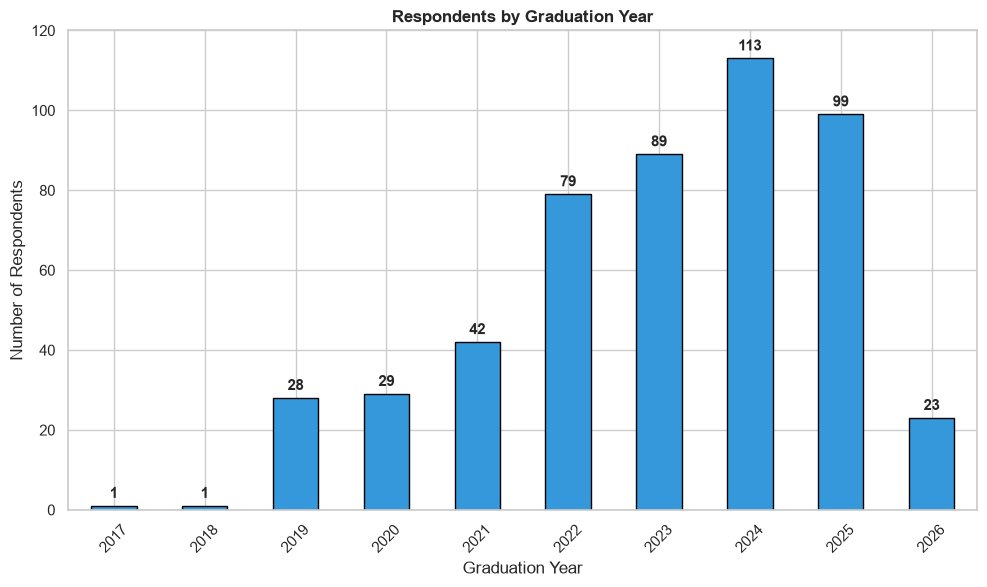

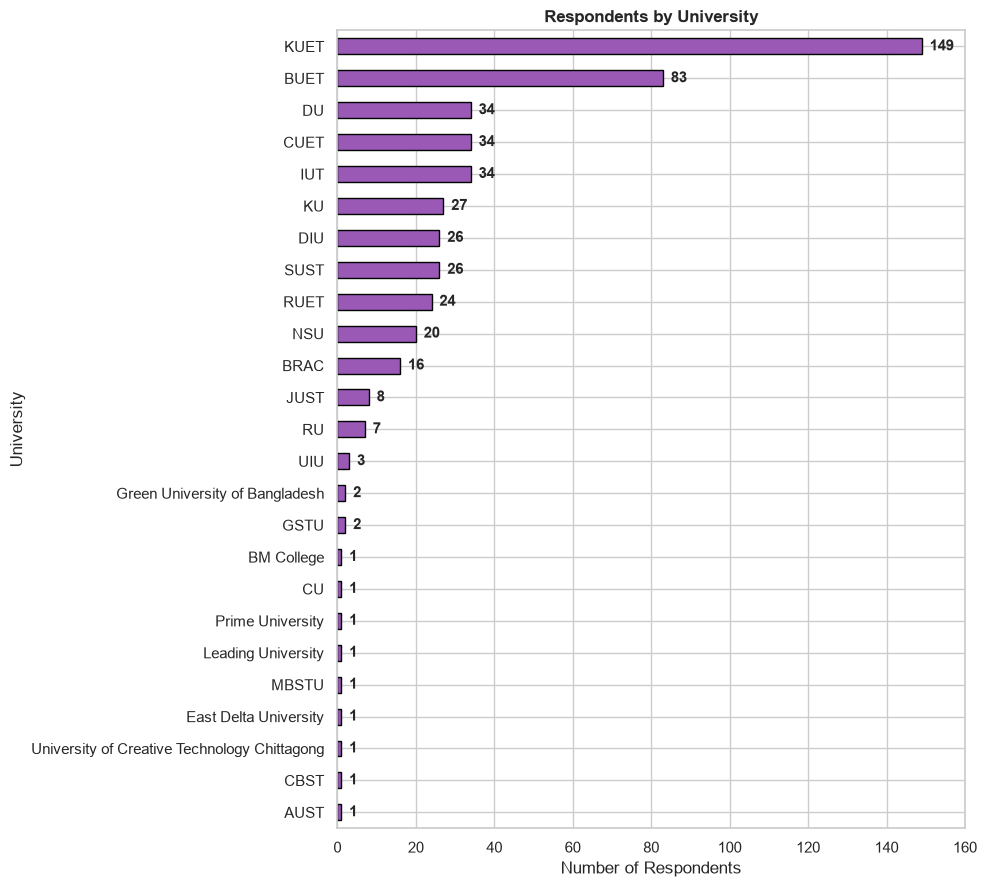

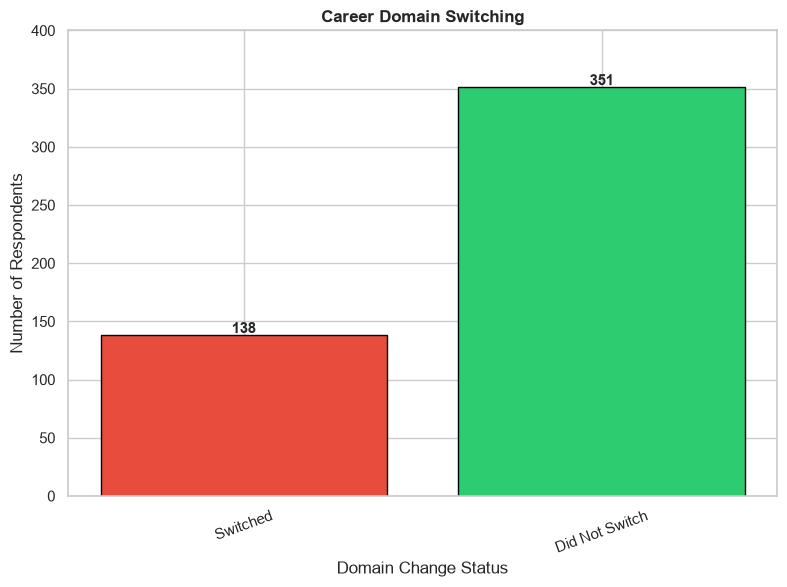

In [5]:
# Plot 1: Graduation batch (separate figure)
from matplotlib.ticker import MultipleLocator
plt.figure(figsize=(10, 6))
batch_counts.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Respondents by Graduation Year', fontweight='bold')
plt.xlabel('Graduation Year')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(MultipleLocator(20))
batch_axis_max = int(np.ceil(batch_counts.max() / 20) * 20)
plt.ylim(0, batch_axis_max)
for i, value in enumerate(batch_counts.values):
    plt.text(i, value + 2, str(value), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: University (separate figure)
plt.figure(figsize=(10, 9))
university_counts.plot(kind='barh', color='#9b59b6', edgecolor='black')
plt.title('Respondents by University', fontweight='bold')
plt.xlabel('Number of Respondents')
plt.ylabel('University')
plt.gca().xaxis.set_major_locator(MultipleLocator(20))
university_axis_max = int(np.ceil(university_counts.max() / 20) * 20)
plt.xlim(0, university_axis_max)
for i, value in enumerate(university_counts.values):
    plt.text(value + 2, i, str(value), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: Domain switching (separate figure)
plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Career Domain Switching', fontweight='bold')
plt.xlabel('Domain Change Status')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_locator(MultipleLocator(50))
domain_axis_max = int(np.ceil(values.max() / 50) * 50)
plt.ylim(0, domain_axis_max)
for i, value in enumerate(values):
    plt.text(i, value + 2, str(value), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## BUET vs KUET Graduate Comparison

This section compares BUET and KUET respondents in terms of graduation batch, professional status, career satisfaction, and career-domain switching.

In [6]:

# BUET vs KUET Comparison Analysis

comparison_df = raw_df.copy()

# Clean university names
comparison_df['University_Group'] = (
    comparison_df.iloc[:, 1]
    .astype(str)
    .str.strip()
)

# Keep only BUET and KUET
comparison_df = comparison_df[
    comparison_df['University_Group'].isin(['BUET', 'KUET'])
].copy()

# Create readable columns
comparison_df['Graduation_Year'] = pd.to_numeric(
    comparison_df.iloc[:, 2],
    errors='coerce'
)

comparison_df['Professional_Status'] = (
    comparison_df.iloc[:, 3]
    .fillna('Not Specified')
    .astype(str)
    .str.strip()
)

comparison_df['Satisfaction_Score'] = pd.to_numeric(
    comparison_df.iloc[:, 18],
    errors='coerce'
)

comparison_df['First_Domain'] = (
    comparison_df.iloc[:, 16]
    .fillna('')
    .astype(str)
    .str.strip()
)

comparison_df['Current_Domain'] = (
    comparison_df.iloc[:, 17]
    .fillna('')
    .astype(str)
    .str.strip()
)

# Domain switching
valid_domain = (
    (comparison_df['First_Domain'] != '') &
    (comparison_df['Current_Domain'] != '')
)

comparison_df['Domain_Switch_Status'] = pd.Series(index=comparison_df.index, dtype='object')

comparison_df.loc[valid_domain, 'Domain_Switch_Status'] = np.where(
    comparison_df.loc[valid_domain, 'First_Domain']
    != comparison_df.loc[valid_domain, 'Current_Domain'],
    'Switched',
    'Did Not Switch'
)

# Respondent count
print("=== BUET vs KUET Respondent Count ===")
respondent_count = (
    comparison_df['University_Group']
    .value_counts()
    .reindex(['BUET', 'KUET'])
)

display(respondent_count.rename('Number of Respondents').to_frame())

# Graduation-year comparison
print("=== Graduation Year Distribution (%) ===")
graduation_comparison = pd.crosstab(
    comparison_df['Graduation_Year'],
    comparison_df['University_Group'],
    normalize='columns'
) * 100

display(graduation_comparison.round(1))

# Professional-status comparison
print("=== Professional Status Distribution (%) ===")
status_comparison = pd.crosstab(
    comparison_df['Professional_Status'],
    comparison_df['University_Group'],
    normalize='columns'
) * 100

display(status_comparison.round(1))

# Satisfaction comparison
print("=== Career Satisfaction Distribution (%) ===")
satisfaction_comparison = pd.crosstab(
    comparison_df['Satisfaction_Score'],
    comparison_df['University_Group'],
    normalize='columns'
) * 100

display(satisfaction_comparison.round(1))

# Domain-switch comparison
print("=== Career Domain Switching (%) ===")
domain_comparison = pd.crosstab(
    comparison_df['Domain_Switch_Status'],
    comparison_df['University_Group'],
    normalize='columns'
) * 100

display(domain_comparison.round(1))

=== BUET vs KUET Respondent Count ===


,Number of Respondents
University_Group,
BUET,83
KUET,149


=== Graduation Year Distribution (%) ===


University_Group,BUET,KUET
Graduation_Year,,
2019,4.8,7.4
2020,12.0,4.0
2021,2.4,4.7
2022,14.5,17.4
2023,19.3,18.1
2024,19.3,18.8
2025,22.9,20.1
2026,4.8,9.4


=== Professional Status Distribution (%) ===


University_Group,BUET,KUET
Professional_Status,,
Currently seeking a job,10.8,14.1
Employed,59.0,67.1
Founder / Entrepreneur,6.0,6.7
Higher studies,20.5,12.1
Not currently seeking,3.6,0.0


=== Career Satisfaction Distribution (%) ===


University_Group,BUET,KUET
Satisfaction_Score,,
1.0,8.6,1.4
2.0,8.6,10.5
3.0,19.8,19.6
4.0,35.8,39.9
5.0,27.2,28.7


=== Career Domain Switching (%) ===


University_Group,BUET,KUET
Domain_Switch_Status,,
Did Not Switch,76.2,71.8
Switched,23.8,28.2


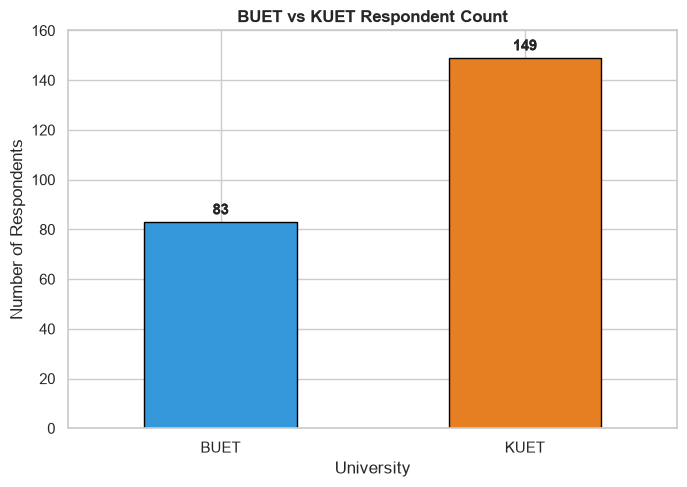

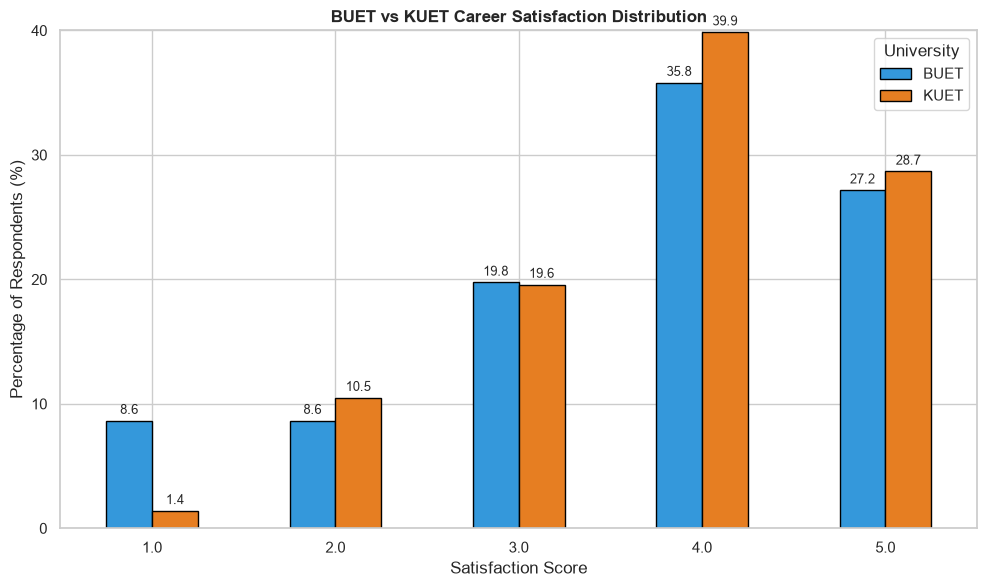

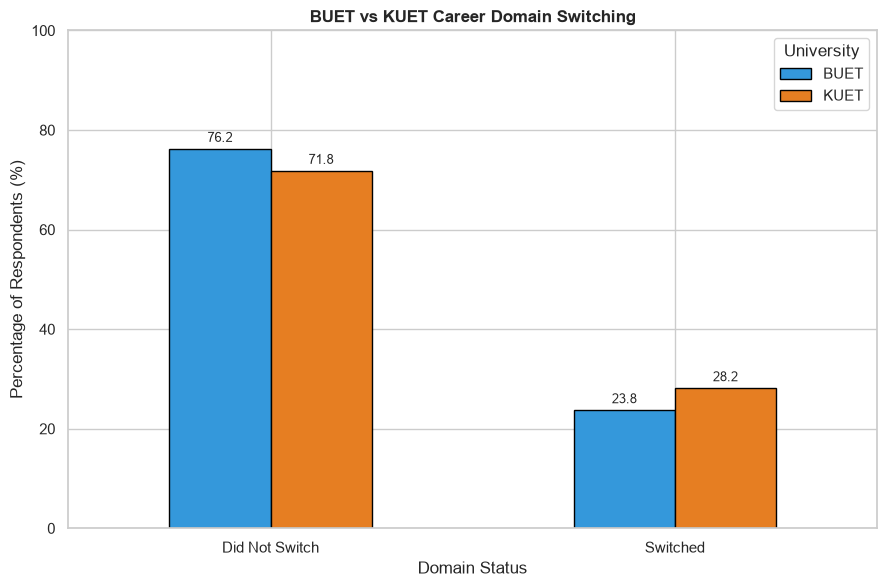

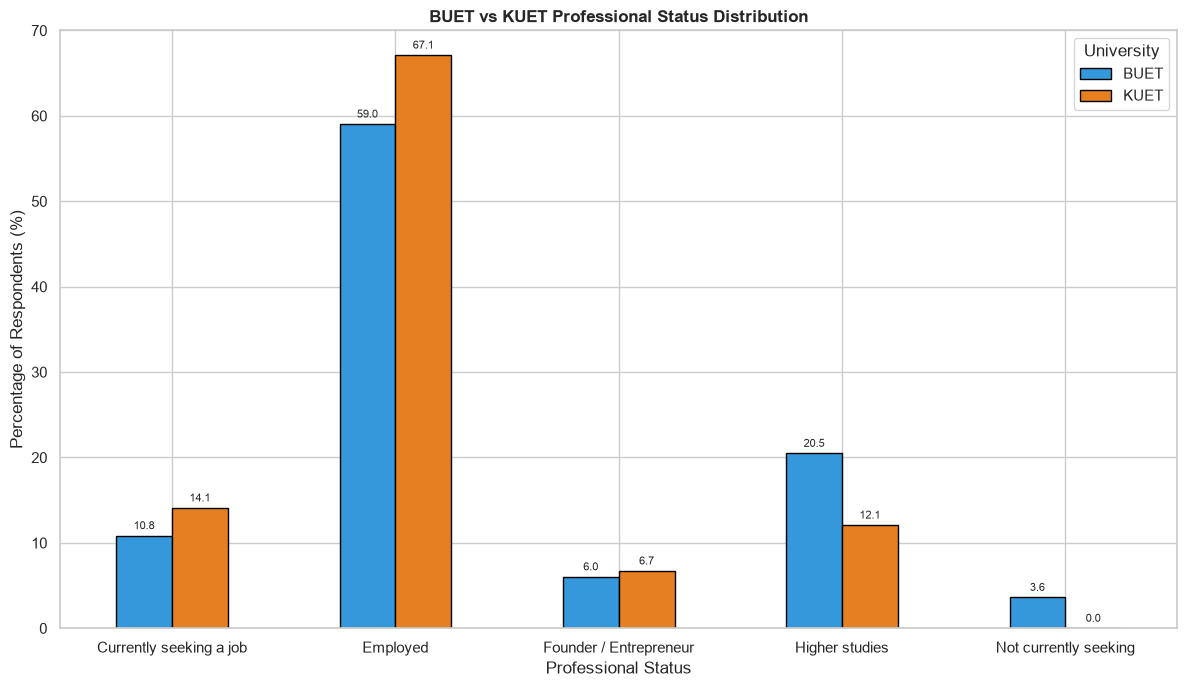

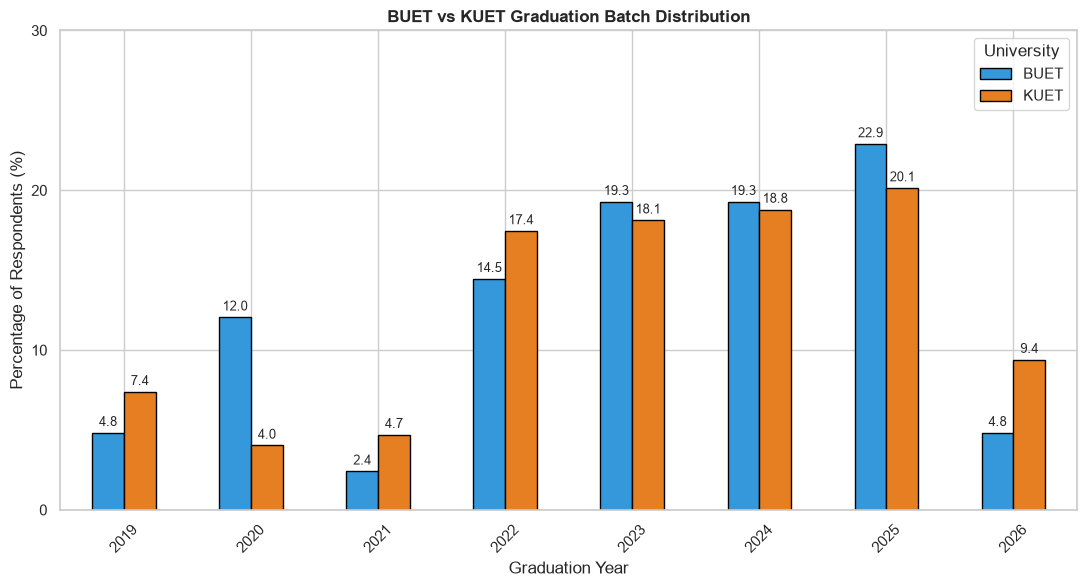

In [7]:
# 1. Respondent count
plt.figure(figsize=(7, 5))

ax = respondent_count.plot(
    kind='bar',
    color=['#3498db', '#e67e22'],
    edgecolor='black'
)

plt.title('BUET vs KUET Respondent Count', fontweight='bold')
plt.xlabel('University')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
respondent_axis_max = int(np.ceil(respondent_count.max() / 20) * 20)
ax.yaxis.set_major_locator(MultipleLocator(20))
ax.set_ylim(0, respondent_axis_max)
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontweight='bold')

for i, value in enumerate(respondent_count.values):
    plt.text(i, value + 3, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 2. Career satisfaction comparison
ax = satisfaction_comparison.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#3498db', '#e67e22'],
    edgecolor='black'
)

plt.title('BUET vs KUET Career Satisfaction Distribution', fontweight='bold')
plt.xlabel('Satisfaction Score')
plt.ylabel('Percentage of Respondents (%)')
plt.xticks(rotation=0)
plt.legend(title='University')
satisfaction_axis_max = max(10, int(np.ceil(satisfaction_comparison.max().max() / 10) * 10))
ax.set_ylim(0, satisfaction_axis_max)
ax.yaxis.set_major_locator(MultipleLocator(10))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


# 3. Domain switching percentage comparison
ax = domain_comparison.plot(
    kind='bar',
    figsize=(9, 6),
    color=['#3498db', '#e67e22'],
    edgecolor='black'
)

plt.title('BUET vs KUET Career Domain Switching', fontweight='bold')
plt.xlabel('Domain Status')
plt.ylabel('Percentage of Respondents (%)')
plt.xticks(rotation=0)
plt.legend(title='University')
plt.ylim(0, 100)
ax.yaxis.set_major_locator(MultipleLocator(20))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


# 4. Professional status comparison
ax = status_comparison.plot(
    kind='bar',
    figsize=(12, 7),
    color=['#3498db', '#e67e22'],
    edgecolor='black'
)

plt.title('BUET vs KUET Professional Status Distribution', fontweight='bold')
plt.xlabel('Professional Status')
plt.ylabel('Percentage of Respondents (%)')
plt.xticks(rotation=0)
plt.legend(title='University')
plt.ylim(0, 100)
professional_axis_max = max(10, int(np.ceil(status_comparison.max().max() / 10) * 10))
ax.set_ylim(0, professional_axis_max)
ax.yaxis.set_major_locator(MultipleLocator(10))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()


# 5. Graduation year comparison
ax = graduation_comparison.plot(
    kind='bar',
    figsize=(11, 6),
    color=['#3498db', '#e67e22'],
    edgecolor='black'
)

plt.title('BUET vs KUET Graduation Batch Distribution', fontweight='bold')
plt.xlabel('Graduation Year')
plt.ylabel('Percentage of Respondents (%)')
plt.xticks(rotation=45)
plt.legend(title='University')
graduation_axis_max = max(10, int(np.ceil(graduation_comparison.max().max() / 10) * 10))
ax.set_ylim(0, graduation_axis_max)
ax.yaxis.set_major_locator(MultipleLocator(10))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## Public, Private and International University Graduate Comparison

This section compares Public, Private and International respondents in terms of graduation batch, professional status, career satisfaction, and career-domain switching.

In [8]:

# Public vs Private vs International Comparison


category_df = raw_df.copy()

# University name cleaning
category_df['University'] = (
    category_df.iloc[:, 1]
    .fillna('Not Specified')
    .astype(str)
    .str.strip()
)

# Institution category mapping
institution_map = {
    # Public
    'KUET': 'Public',
    'BUET': 'Public',
    'DU': 'Public',
    'CUET': 'Public',
    'KU': 'Public',
    'SUST': 'Public',
    'RUET': 'Public',
    'JUST': 'Public',
    'RU': 'Public',
    'GSTU': 'Public',
    'BM College': 'Public',
    'CU': 'Public',
    'MBSTU': 'Public',
    'University': 'Public',

    # Private
    'DIU': 'Private',
    'NSU': 'Private',
    'BRAC': 'Private',
    'UIU': 'Private',
    'Green University of Bangladesh': 'Private',
    'Prime University': 'Private',
    'Leading University': 'Private',
    'East Delta University': 'Private',
    'University of Creative Technology Chittagong': 'Private',
    'CBST': 'Private',
    'AUST': 'Private',

    # International
    'IUT': 'International'
}

category_df['Institution_Type'] = category_df['University'].map(institution_map)

category_df = category_df.dropna(
    subset=['Institution_Type']
).copy()

# Basic columns
category_df['Graduation_Year'] = pd.to_numeric(
    category_df.iloc[:, 2],
    errors='coerce'
)

category_df['Professional_Status'] = (
    category_df.iloc[:, 3]
    .fillna('Not Specified')
    .astype(str)
    .str.strip()
)

category_df['Satisfaction_Score'] = pd.to_numeric(
    category_df.iloc[:, 18],
    errors='coerce'
)

# Domain switching
category_df['First_Domain'] = (
    category_df.iloc[:, 16]
    .fillna('')
    .astype(str)
    .str.strip()
)

category_df['Current_Domain'] = (
    category_df.iloc[:, 17]
    .fillna('')
    .astype(str)
    .str.strip()
)

valid_domain = (
    (category_df['First_Domain'] != '') &
    (category_df['Current_Domain'] != '')
)

category_df['Domain_Switch_Status'] = np.where(
    valid_domain,
    np.where(
        category_df['First_Domain']
        != category_df['Current_Domain'],
        'Switched',
        'Did Not Switch'
    ),
    'Not Specified'
)

# Combined Result Tables

category_order = ['Public', 'Private', 'International']

# 1. Respondent count and average satisfaction
combined_result = (
    category_df
    .groupby('Institution_Type')
    .agg(
        Respondents=('Institution_Type', 'size'),
        Average_Satisfaction=('Satisfaction_Score', 'mean')
    )
    .reindex(category_order)
)

print("=== Combined Institution-Type Result ===")
display(combined_result.round(2))

# 2. Graduation year distribution
graduation_result = pd.crosstab(
    category_df['Graduation_Year'],
    category_df['Institution_Type'],
    normalize='columns'
) * 100

graduation_result = graduation_result.reindex(
    columns=category_order
)

print("=== Graduation Year Distribution (%) ===")
display(graduation_result.round(1))

# 3. Professional status distribution
status_result = pd.crosstab(
    category_df['Professional_Status'],
    category_df['Institution_Type'],
    normalize='columns'
) * 100

status_result = status_result.reindex(
    columns=category_order
)

print("=== Professional Status Distribution (%) ===")
display(status_result.round(1))

# 4. Satisfaction score distribution
satisfaction_result = pd.crosstab(
    category_df['Satisfaction_Score'],
    category_df['Institution_Type'],
    normalize='columns'
) * 100

satisfaction_result = satisfaction_result.reindex(
    columns=category_order
)

print("=== Career Satisfaction Distribution (%) ===")
display(satisfaction_result.round(1))

# 5. Domain switching distribution
domain_result = pd.crosstab(
    category_df['Domain_Switch_Status'],
    category_df['Institution_Type'],
    normalize='columns'
) * 100

domain_result = domain_result.reindex(
    columns=category_order
)

print("=== Career Domain Switching Distribution (%) ===")
display(domain_result.round(1))

=== Combined Institution-Type Result ===


,Respondents,Average_Satisfaction
Institution_Type,,
Public,397,3.81
Private,73,3.67
International,34,3.91


=== Graduation Year Distribution (%) ===


Institution_Type,Public,Private,International
Graduation_Year,,,
2017,0.0,1.4,0.0
2018,0.3,0.0,0.0
2019,6.5,2.7,0.0
2020,6.3,4.1,2.9
2021,8.1,13.7,0.0
2022,17.1,12.3,5.9
2023,16.9,12.3,38.2
2024,20.7,21.9,44.1
2025,19.6,26.0,5.9


=== Professional Status Distribution (%) ===


Institution_Type,Public,Private,International
Professional_Status,,,
Currently seeking a job,10.6,16.4,2.9
Employed,65.5,56.2,73.5
Founder / Entrepreneur,7.1,12.3,14.7
Higher studies,16.1,12.3,8.8
Not currently seeking,0.8,2.7,0.0


=== Career Satisfaction Distribution (%) ===


Institution_Type,Public,Private,International
Satisfaction_Score,,,
1.0,2.8,8.3,2.9
2.0,6.7,5.6,5.9
3.0,24.4,22.2,23.5
4.0,38.6,38.9,32.4
5.0,27.5,25.0,35.3


=== Career Domain Switching Distribution (%) ===


Institution_Type,Public,Private,International
Domain_Switch_Status,,,
Did Not Switch,70.3,60.3,82.4
Not Specified,3.5,1.4,0.0
Switched,26.2,38.4,17.6


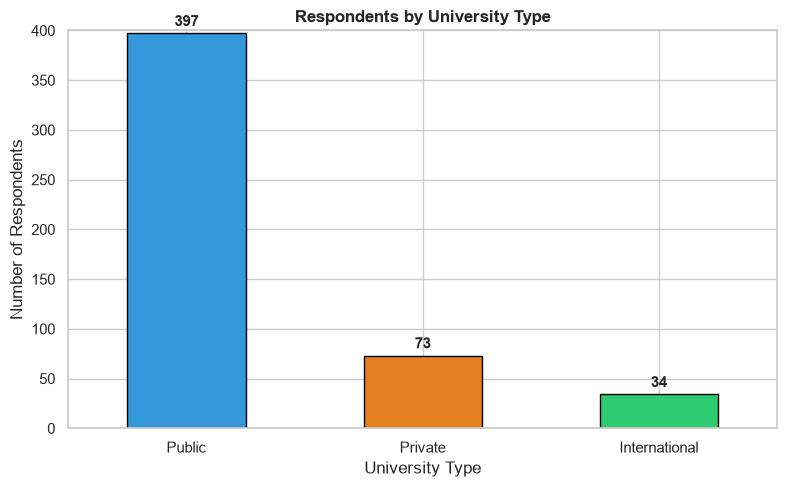

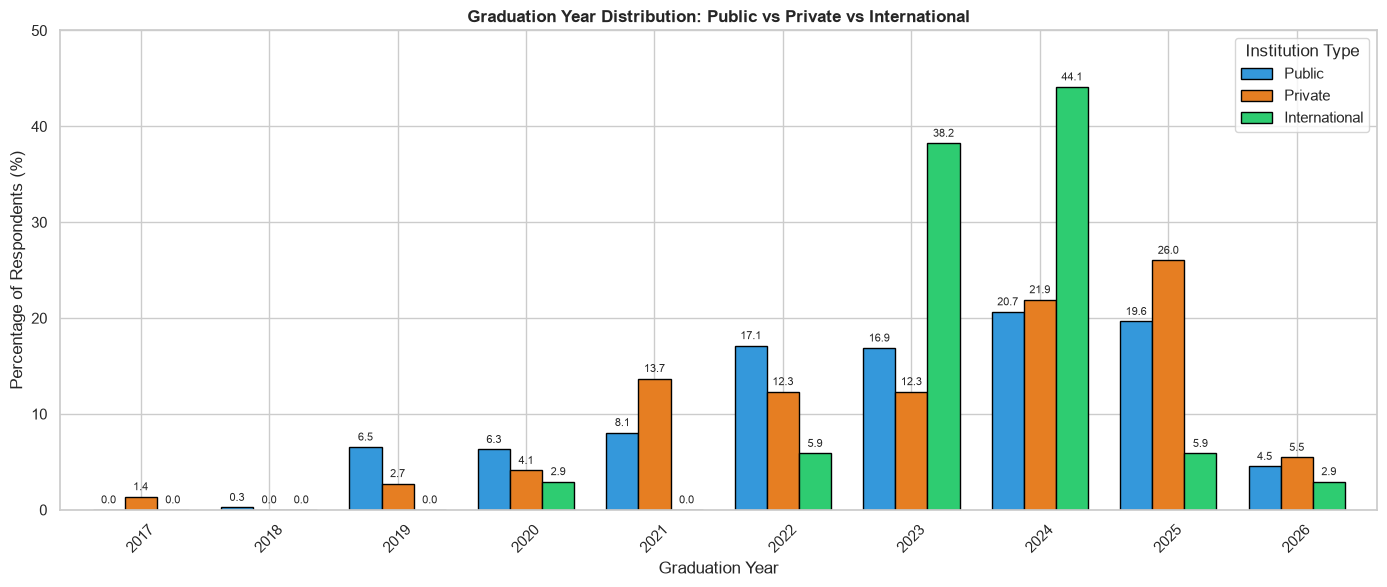

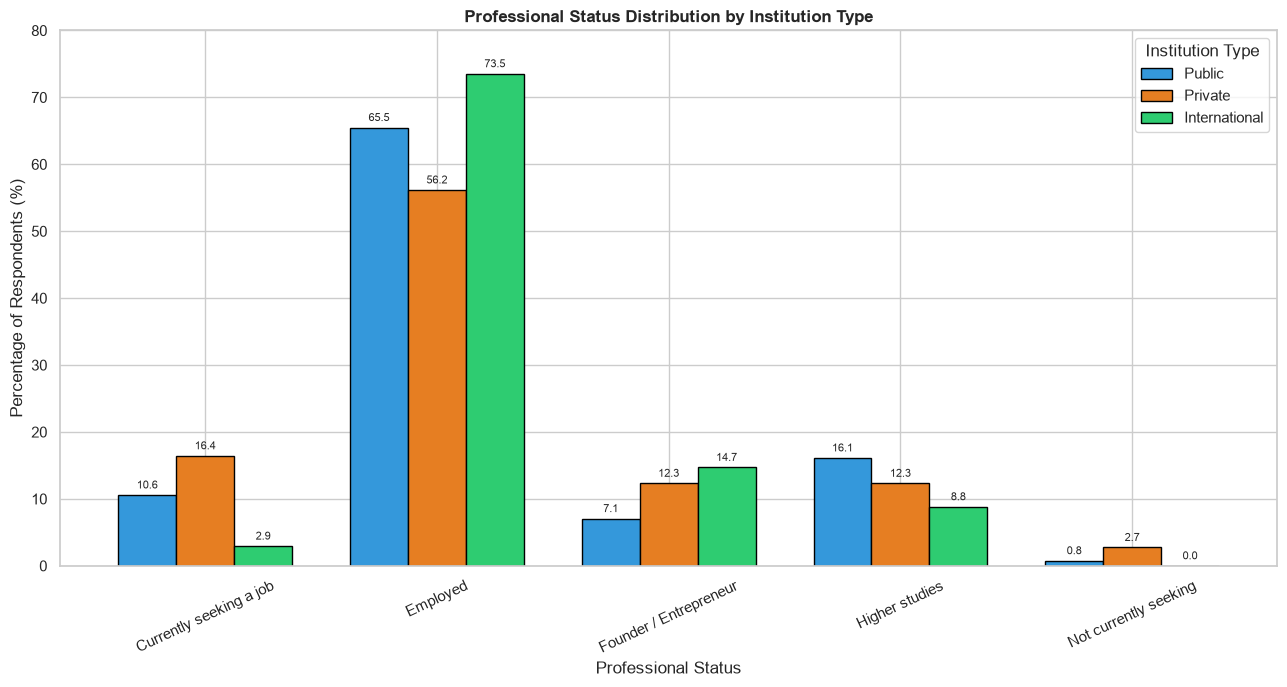

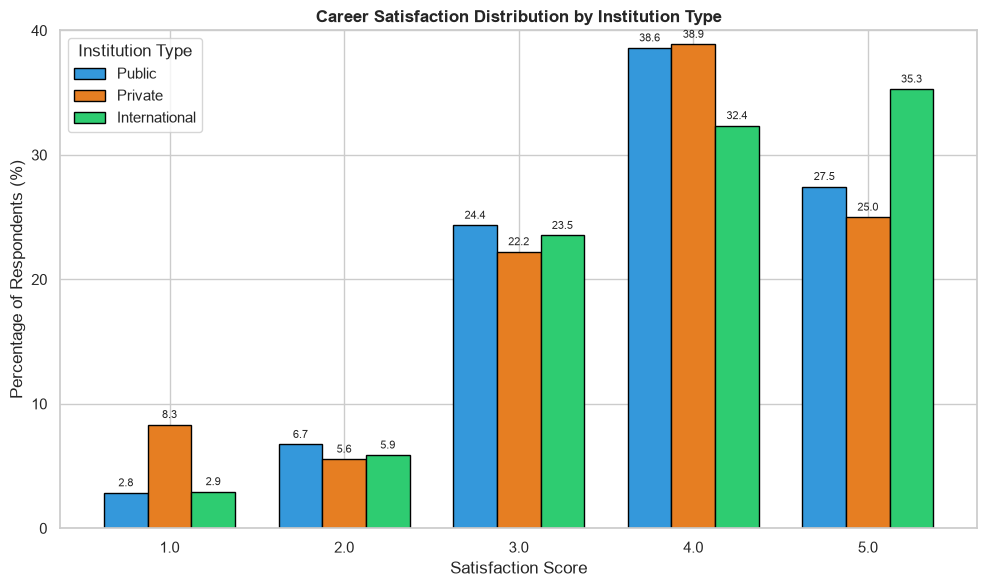

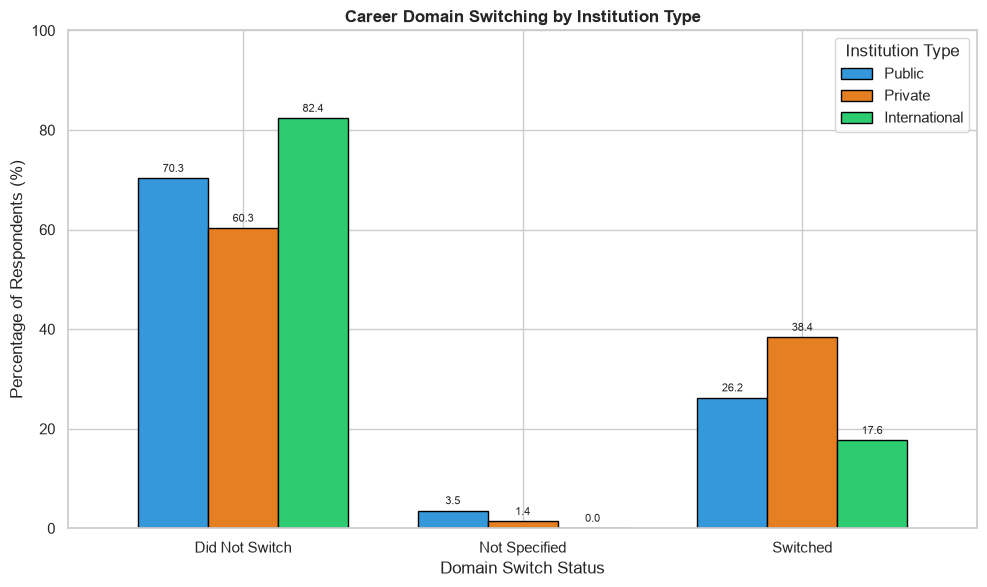

In [9]:
def grouped_bar_plot(data, title, xlabel, ylabel,
                     figsize=(10, 6), percentage=True,
                     dynamic_axis=False,
                     tick_step=20,
                     rotation=0):

    ax = data.plot(
        kind='bar',
        figsize=figsize,
        width=0.75,
        color=['#3498db', '#e67e22', '#2ecc71'],
        edgecolor='black'
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    ax.legend(title='Institution Type')

    # Percentage plot axis
    if percentage:
        if dynamic_axis:
            highest_value = float(data.max().max())
            axis_max = max(tick_step, int(np.ceil(highest_value / tick_step) * tick_step))
            ax.set_ylim(0, axis_max)
        else:
            ax.set_ylim(0, 100)
        ax.yaxis.set_major_locator(MultipleLocator(tick_step))

    # Show values above every bar
    for container in ax.containers:
        labels = []

        for bar in container:
            height = bar.get_height()
            labels.append(
                '' if np.isnan(height) else f'{height:.1f}'
            )

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=8
        )

    plt.tight_layout()
    plt.show()


# 1. Respondent count
ax = combined_result['Respondents'].plot(
    kind='bar',
    figsize=(8, 5),
    color=['#3498db', '#e67e22', '#2ecc71'],
    edgecolor='black'
)

ax.set_title('Respondents by University Type', fontweight='bold')
ax.set_xlabel('University Type')
ax.set_ylabel('Number of Respondents')
ax.tick_params(axis='x', rotation=0)

respondent_axis_max = int(
    np.ceil(combined_result['Respondents'].max() / 50) * 50
)

ax.set_ylim(0, respondent_axis_max)
ax.yaxis.set_major_locator(MultipleLocator(50))
ax.bar_label(ax.containers[0], padding=3, fontweight='bold')

plt.tight_layout()
plt.show()


# 2. Graduation year
grouped_bar_plot(
    graduation_result,
    'Graduation Year Distribution: Public vs Private vs International',
    'Graduation Year',
    'Percentage of Respondents (%)',
    figsize=(14, 6),
    rotation=45,
    dynamic_axis=True,
    tick_step=10
)


# 3. Professional status
grouped_bar_plot(
    status_result,
    'Professional Status Distribution by Institution Type',
    'Professional Status',
    'Percentage of Respondents (%)',
    figsize=(13, 7),
    rotation=25,
    dynamic_axis=True,
    tick_step=10
)


# 4. Satisfaction score
grouped_bar_plot(
    satisfaction_result,
    'Career Satisfaction Distribution by Institution Type',
    'Satisfaction Score',
    'Percentage of Respondents (%)',
    figsize=(10, 6),
    dynamic_axis=True,
    tick_step=10
)


# 5. Career domain switching
grouped_bar_plot(
    domain_result,
    'Career Domain Switching by Institution Type',
    'Domain Switch Status',
    'Percentage of Respondents (%)',
    figsize=(10, 6)
)

## 3. Target Variable Definition & 5-Class Satisfaction Labels
### Preprocessing Rationale:
1. **Target Column (Col 18)**: Survey Question 14 (*"How satisfied are you with your current career path?"*), originally rated on a 1–5 Likert scale.
2. **Missing Target Handling**: 12 rows lack a target rating ($N = 504 
ightarrow 492$). In supervised learning, target labels are **strictly dropped** rather than imputed to avoid introducing synthetic label noise.
3. **Five Satisfaction Classes**:
   - **Very Dissatisfied** (Rating 1)
   - **Dissatisfied** (Rating 2)
   - **Neutral** (Rating 3)
   - **Satisfied** (Rating 4)
   - **Very Satisfied** (Rating 5)
4. **Original Likert labels retained**: Each 1–5 response is used as a separate target class.

In [10]:
# Step 3.1: Identify target column
target_col_raw = raw_df.columns[18]

# Step 3.2: Drop missing target rows
df = raw_df.dropna(subset=[target_col_raw]).reset_index(drop=True)
print(f"Valid Supervised Modeling Instances: N = {len(df)}")

# Step 3.3: Preserve all 5 Satisfaction Levels with descriptive labels
satisfaction_labels = {
    1.0: 'Very Dissatisfied',
    2.0: 'Dissatisfied',
    3.0: 'Neutral',
    4.0: 'Satisfied',
    5.0: 'Very Satisfied'
}
df['Target_5Class'] = df[target_col_raw].map(satisfaction_labels)

# Step 3.4: Display Target Distribution Table
target_summary = pd.DataFrame({
    'Raw Likert Scale Values': ['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],
    'Instance Count (N)': [
        (df['Target_5Class'] == label).sum() for label in satisfaction_labels.values()
    ],
    'Proportion (%)': [
        f"{(df['Target_5Class'] == label).mean():.1%}" for label in satisfaction_labels.values()
    ]
}, index=list(satisfaction_labels.values()))

print("\n=== 5-Class Career Satisfaction Target Distribution ===")
display(target_summary)

Valid Supervised Modeling Instances: N = 492

=== 5-Class Career Satisfaction Target Distribution ===


,Raw Likert Scale Values,Instance Count (N),Proportion (%)
Very Dissatisfied,Rating 1,18,3.7%
Dissatisfied,Rating 2,32,6.5%
Neutral,Rating 3,118,24.0%
Satisfied,Rating 4,188,38.2%
Very Satisfied,Rating 5,136,27.6%


## Common characterisics of Rating-5 providing Graduates

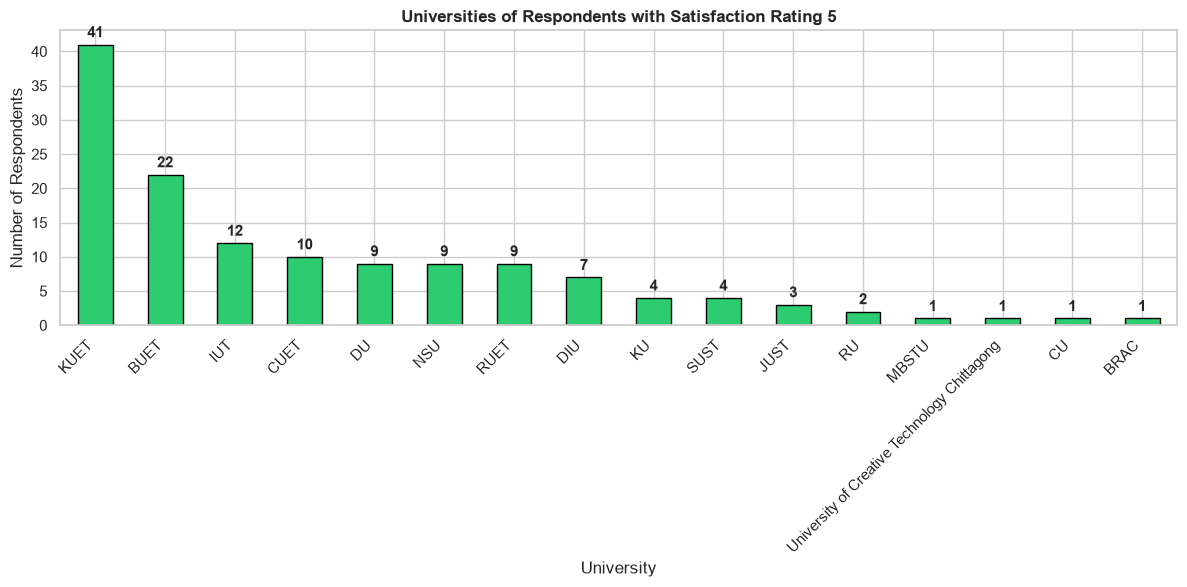

In [11]:
# Rating 5 respondents
rating_5_df = raw_df[raw_df.iloc[:, 18] == 5].copy()

# University names are already normalized in raw_df
rating_5_df['University'] = rating_5_df['University_Name']

# University-wise respondent count
rating_5_university = (
    rating_5_df['University']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
ax = rating_5_university.plot(
    kind='bar',
    color='#2ecc71',
    edgecolor='black'
)

plt.title('Universities of Respondents with Satisfaction Rating 5',
          fontweight='bold')
plt.xlabel('University')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')

ax.bar_label(ax.containers[0], padding=3, fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Selected numeric characteristics of Rating 5 respondents
numeric_characteristic_cols = [
    'University_Studies_Effect', 'Help_Lecture', 'Help_Lab',
    'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network',
    'Software_Projects_Built', 'Problem_Solving_Ability',
    'AI_Programming_Reliance'
]
rating_5_numeric = rating_5_df[numeric_characteristic_cols].apply(
    pd.to_numeric, errors='coerce'
)
display(rating_5_numeric.describe().T)

,count,mean,std,min,25%,50%,75%,max
University_Studies_Effect,136.0,3.058824,1.654465,0.0,2.00,3.0,4.0,5.0
Help_Lecture,136.0,2.882353,1.445600,1.0,1.75,3.0,4.0,5.0
Help_Lab,136.0,2.801471,1.381464,1.0,2.00,3.0,4.0,5.0
Help_Thesis_Group_Work,136.0,3.161765,1.410125,1.0,2.00,3.0,4.0,5.0
Help_Club_Activities,136.0,2.875000,1.467866,1.0,1.75,3.0,4.0,5.0
Help_Alumni_Network,136.0,2.860294,1.516198,1.0,1.00,3.0,4.0,5.0
Software_Projects_Built,35.0,2.742857,1.421326,0.0,2.00,3.0,4.0,4.0
Problem_Solving_Ability,136.0,3.411765,0.962024,1.0,3.00,3.0,4.0,5.0
AI_Programming_Reliance,136.0,3.500000,1.192570,1.0,3.00,4.0,4.0,5.0


In [13]:
# Most common meaningful responses among Rating 5 respondents
# Timestamp, university, target rating, and free-text suggestions are excluded.
categorical_cols = [
    'Professional_Status', 'Club_Participation',
    'Internship_Part_Time_Freelance', 'GitHub_Maintenance',
    'Programming_Contest_Involvement', 'First_Career_Domain',
    'Current_Career_Domain', 'Future_Domain_Shift',
    'AI_Usage_Frequency', 'AI_Concerns_Opinion'
]

common_characteristics = {}

for col in categorical_cols:
    mode_values = rating_5_df[col].dropna().mode()
    if len(mode_values) > 0:
        common_characteristics[col] = mode_values.iloc[0]

common_characteristics_df = pd.DataFrame(
    list(common_characteristics.items()),
    columns=['Feature', 'Most Common Response']
)

display(common_characteristics_df)

,Feature,Most Common Response
0,Professional_Status,Employed
1,Club_Participation,Programming
2,Internship_Part_Time_Freelance,No
3,GitHub_Maintenance,Actively maintained
4,Programming_Contest_Involvement,Occasionally
5,First_Career_Domain,Software Engineer
6,Current_Career_Domain,Software Engineer
7,Future_Domain_Shift,No
8,AI_Usage_Frequency,Constantly
9,AI_Concerns_Opinion,Positive


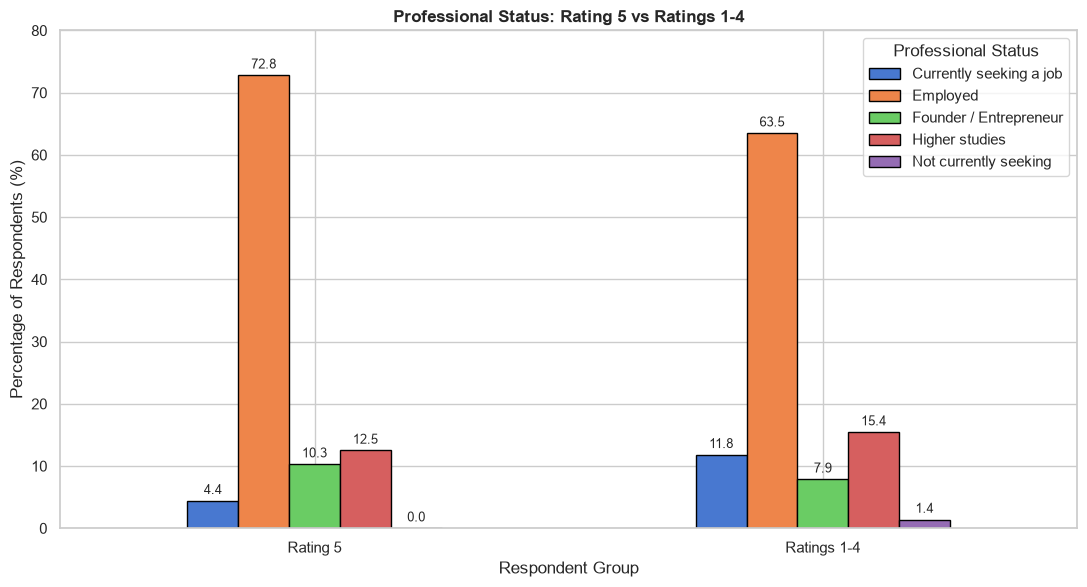

In [14]:
from matplotlib.ticker import MultipleLocator

rating_5_df['Group'] = 'Rating 5'
other_df = raw_df[
    raw_df.iloc[:, 18].notna() & (raw_df.iloc[:, 18] != 5)
].copy()
other_df['Group'] = 'Ratings 1-4'

rating5_vs_rest_df = pd.concat([rating_5_df, other_df])

# Example: professional status comparison
status_comparison = pd.crosstab(
    rating5_vs_rest_df['Group'],
    rating5_vs_rest_df.iloc[:, 3],
    normalize='index'
) * 100

ax = status_comparison.plot(
    kind='bar',
    figsize=(11, 6),
    edgecolor='black'
)

plt.title('Professional Status: Rating 5 vs Ratings 1-4',
          fontweight='bold')
plt.ylabel('Percentage of Respondents (%)')
plt.xlabel('Respondent Group')
plt.xticks(rotation=0)
plt.legend(title='Professional Status')

# Dynamic y-axis: round the maximum percentage up to the next 10
highest_value = float(status_comparison.max().max())
axis_max = max(10, int(np.ceil(highest_value / 10) * 10))
ax.set_ylim(0, axis_max)
ax.yaxis.set_major_locator(MultipleLocator(10))

# Show the percentage on every bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Exploratory Impact Analysis: Column 19 (Domain Shift Intent)
We examine the empirical relationship between **Domain Shift Intent (Column 19: *"Do you expect to shift to a different domain in the future?"*)** and **Career Satisfaction**.
- **Graduates answering `No`:** Display **74.0% High satisfaction** and only **5.0% Low satisfaction**.
- **Graduates answering `Yes`:** Display **63.7% Low/Medium dissatisfaction**.
- **Conclusion:** Column 19 provides strong signal representing career alignment and retention risk, and is explicitly included in the model.

=== Cross-Tabulation: Domain Shift Intent (Col 19) vs Target (Counts) ===


Target_5Class,Dissatisfied,Neutral,Satisfied,Very Dissatisfied,Very Satisfied,All
Future_Domain_Shift,,,,,,
Maybe,4,24,44,8,16,96
No,13,59,110,6,102,290
Not Specified,0,0,1,0,1,2
Yes,15,35,33,4,17,104
All,32,118,188,18,136,492



=== Row-Wise Percentage Distribution (%) ===


Target_5Class,Dissatisfied,Neutral,Satisfied,Very Dissatisfied,Very Satisfied
Future_Domain_Shift,,,,,
Maybe,4.2,25.0,45.8,8.3,16.7
No,4.5,20.3,37.9,2.1,35.2
Not Specified,0.0,0.0,50.0,0.0,50.0
Yes,14.4,33.7,31.7,3.8,16.3


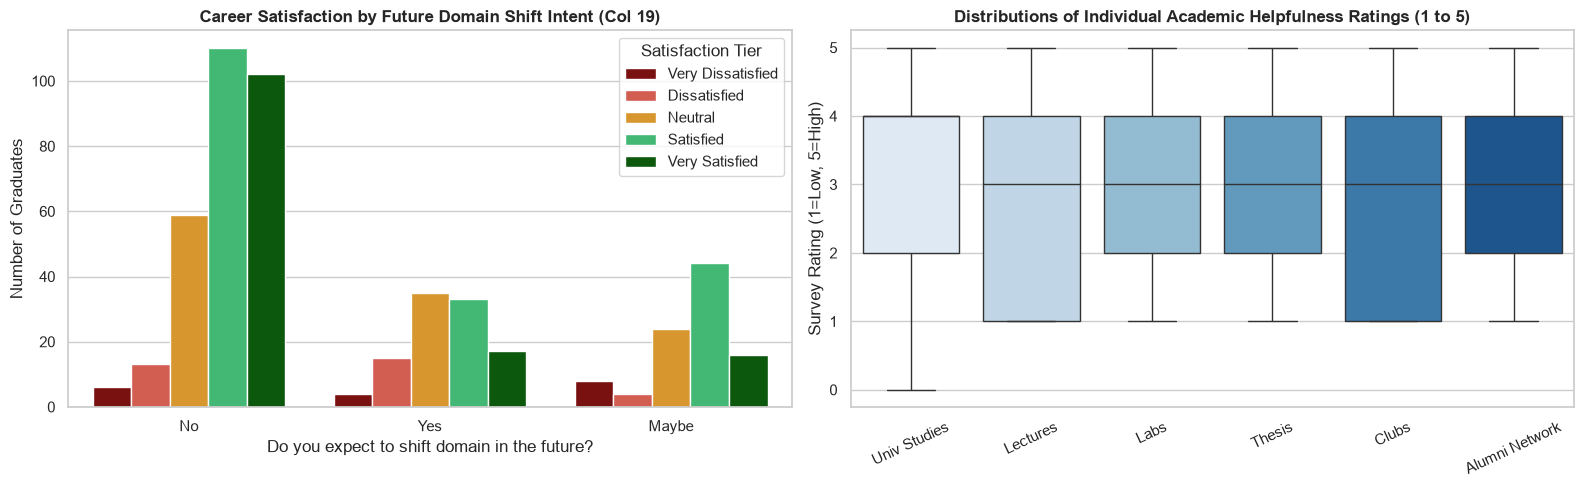

In [15]:
col19_name = raw_df.columns[19]

# Cross-tabulation table
ct_counts = pd.crosstab(df[col19_name].fillna('Not Specified'), df['Target_5Class'], margins=True)
ct_perc = pd.crosstab(df[col19_name].fillna('Not Specified'), df['Target_5Class'], normalize='index') * 100

print("=== Cross-Tabulation: Domain Shift Intent (Col 19) vs Target (Counts) ===")
display(ct_counts)
print("\n=== Row-Wise Percentage Distribution (%) ===")
display(ct_perc.round(1))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x=col19_name, hue='Target_5Class', hue_order=list(satisfaction_labels.values()),
              palette=['#8b0000', '#e74c3c', '#f39c12', '#2ecc71', '#006400'], ax=axes[0])
axes[0].set_title('Career Satisfaction by Future Domain Shift Intent (Col 19)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Do you expect to shift domain in the future?')
axes[0].set_ylabel('Number of Graduates')
axes[0].legend(title='Satisfaction Tier')

# Academic components boxplots
acad_cols_raw = [raw_df.columns[4], raw_df.columns[5], raw_df.columns[6], raw_df.columns[7], raw_df.columns[8], raw_df.columns[9]]
acad_names = ['Univ Studies', 'Lectures', 'Labs', 'Thesis', 'Clubs', 'Alumni Network']
acad_df = df[acad_cols_raw].copy()
acad_df.columns = acad_names

sns.boxplot(data=acad_df, palette='Blues', ax=axes[1])
axes[1].set_title('Distributions of Individual Academic Helpfulness Ratings (1 to 5)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Survey Rating (1=Low, 5=High)')
axes[1].set_xticklabels(acad_names, rotation=25)

plt.tight_layout()
plt.show()

## 4.1 Common Characteristics of Low-Satisfaction Students (Ratings 1 & 2)
To address **Requirement (1)**, we isolate and profile graduates who reported low career satisfaction—specifically **Rating 1 ('Very Dissatisfied')** and **Rating 2 ('Dissatisfied')**.

- **Cohort Definition:** We aggregate Likert Ratings 1 and 2 into a consolidated Low-Satisfaction cohort. Grouping these two categories provides statistical stability while isolating graduates facing severe career friction.
- **Dynamic Sample Size Verification:** Rather than assuming static counts, all sample sizes and proportions are computed dynamically directly from the active dataset.
- **Profiling Dimensions:** We analyze institutional demographics, employment statuses, Likert ratings across academic helpfulness, self-assessed technical capabilities, and AI interaction patterns.

=== Low-Satisfaction Cohort Verification ===
Total Valid Survey Responses: N = 492
Low-Satisfaction Students (Ratings 1 & 2): N = 50 (10.2% of total)
  - Rating 1 (Very Dissatisfied): N = 18 (3.7%)
  - Rating 2 (Dissatisfied)     : N = 32 (6.5%)


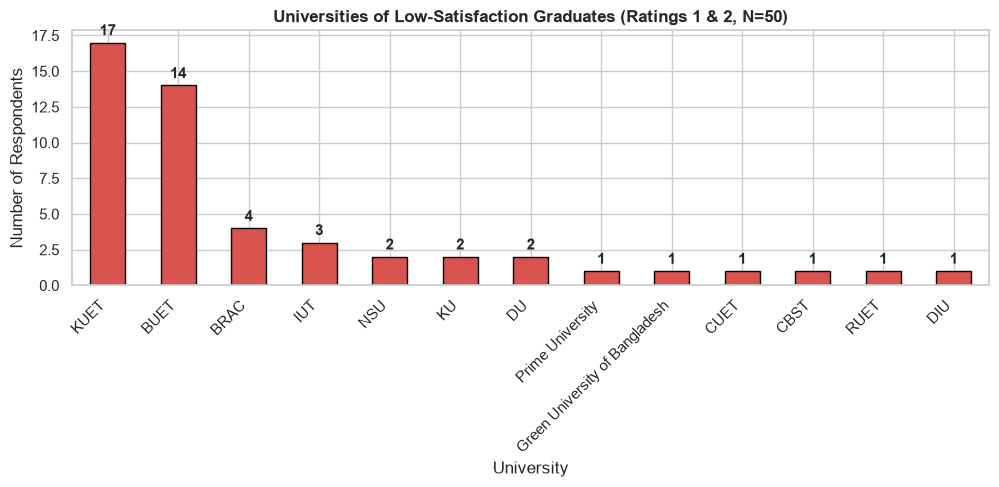

In [16]:
# Dynamic extraction of the Low-Satisfaction cohort (Ratings 1 & 2)
target_num_col = pd.to_numeric(df[raw_df.columns[18]], errors='coerce')
low_sat_mask = target_num_col.isin([1, 2])
low_sat_df = df[low_sat_mask].copy()

n_total = len(df)
n_low = len(low_sat_df)
n_r1 = int((target_num_col == 1).sum())
n_r2 = int((target_num_col == 2).sum())
pct_low = (n_low / n_total) * 100

print(f"=== Low-Satisfaction Cohort Verification ===")
print(f"Total Valid Survey Responses: N = {n_total}")
print(f"Low-Satisfaction Students (Ratings 1 & 2): N = {n_low} ({pct_low:.1f}% of total)")
print(f"  - Rating 1 (Very Dissatisfied): N = {n_r1} ({(n_r1/n_total)*100:.1f}%)")
print(f"  - Rating 2 (Dissatisfied)     : N = {n_r2} ({(n_r2/n_total)*100:.1f}%)")

# Institutional representation among low-satisfaction graduates
univ_counts_low = low_sat_df['University_Name'].value_counts()

plt.figure(figsize=(10, 5))
ax = univ_counts_low.plot(kind='bar', color='#d9534f', edgecolor='black')
plt.title(f'Universities of Low-Satisfaction Graduates (Ratings 1 & 2, N={n_low})', fontweight='bold')
plt.xlabel('University')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold')
plt.tight_layout()
plt.show()

=== Numeric & Likert Characteristics of Low-Satisfaction Graduates (N=50) ===


,count,mean,std,min,25%,50%,75%,max,IQR
University_Studies_Effect,50.0,2.84,1.65,0.0,2.0,3.0,4.00,5.0,2.00
Help_Lecture,50.0,2.70,1.54,1.0,1.0,2.0,4.00,5.0,3.00
Help_Lab,50.0,2.58,1.46,1.0,1.0,2.0,4.00,5.0,3.00
Help_Thesis_Group_Work,50.0,3.04,1.23,1.0,2.0,3.0,4.00,5.0,2.00
Help_Club_Activities,50.0,2.60,1.44,1.0,1.0,3.0,3.75,5.0,2.75
Help_Alumni_Network,50.0,2.66,1.42,1.0,1.0,2.0,4.00,5.0,3.00
Software_Projects_Built,12.0,2.42,1.24,0.0,2.0,2.0,3.25,4.0,1.25
Problem_Solving_Ability,50.0,3.56,0.95,1.0,3.0,3.5,4.00,5.0,1.00
AI_Programming_Reliance,50.0,3.88,0.98,2.0,3.0,4.0,5.00,5.0,2.00


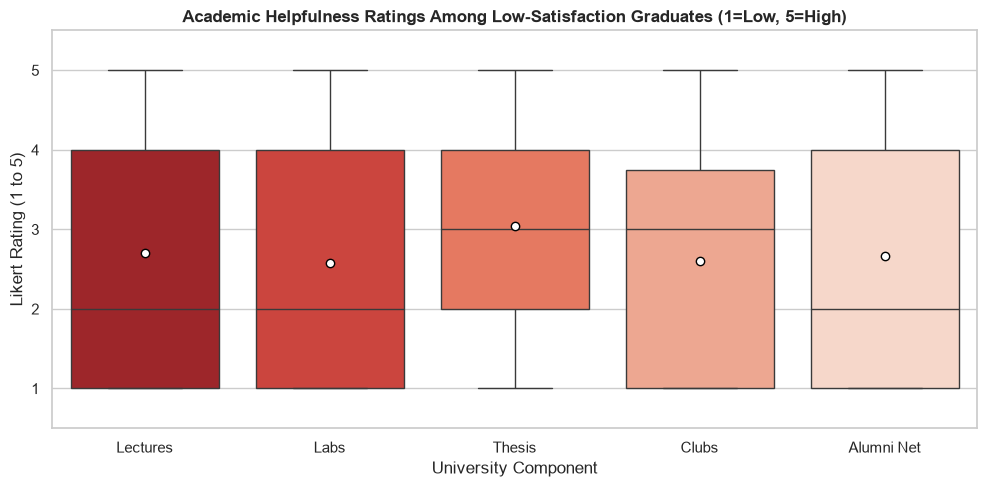

In [17]:
# Numeric & Likert scale summary statistics for Low-Satisfaction graduates
numeric_characteristic_cols = [
    'University_Studies_Effect', 'Help_Lecture', 'Help_Lab',
    'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network',
    'Software_Projects_Built', 'Problem_Solving_Ability',
    'AI_Programming_Reliance'
]

low_sat_numeric = low_sat_df[numeric_characteristic_cols].apply(pd.to_numeric, errors='coerce')
low_num_summary = low_sat_numeric.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
low_num_summary['IQR'] = low_num_summary['75%'] - low_num_summary['25%']

print(f"=== Numeric & Likert Characteristics of Low-Satisfaction Graduates (N={n_low}) ===")
display(low_num_summary.round(2))

# Visualizing distributions across academic helpfulness ratings in low-satisfaction cohort
acad_cols = ['Help_Lecture', 'Help_Lab', 'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network']
acad_labels = ['Lectures', 'Labs', 'Thesis', 'Clubs', 'Alumni Net']
acad_low_df = low_sat_df[acad_cols].apply(pd.to_numeric, errors='coerce')
acad_low_df.columns = acad_labels

plt.figure(figsize=(10, 5))
sns.boxplot(data=acad_low_df, palette='Reds_r', showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Academic Helpfulness Ratings Among Low-Satisfaction Graduates (1=Low, 5=High)', fontweight='bold')
plt.ylabel('Likert Rating (1 to 5)')
plt.xlabel('University Component')
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

=== Most Common Categorical Traits Among Low-Satisfaction Graduates ===


,Survey Feature,Most Common Response (Mode),Mode Frequency (%)
0,Professional_Status,Employed,52.0%
1,Club_Participation,Programming,20.0%
2,Internship_Part_Time_Freelance,Yes,54.0%
3,GitHub_Maintenance,Occasionally maintained,46.0%
4,Programming_Contest_Involvement,Occasionally,36.0%
5,First_Career_Domain,Software Engineer,34.0%
6,Current_Career_Domain,Software Engineer,28.0%
7,Future_Domain_Shift,No,38.0%
8,AI_Usage_Frequency,Constantly,78.0%
9,AI_Concerns_Opinion,Positive,38.0%


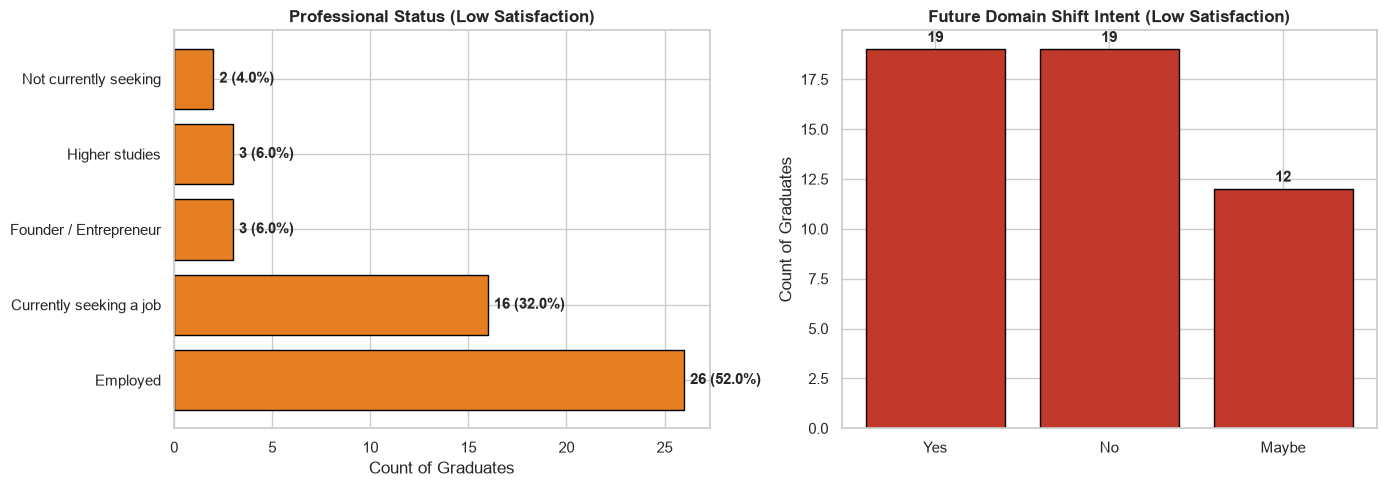

In [18]:
# Categorical modal responses and key distributional traits
categorical_cols = [
    'Professional_Status', 'Club_Participation',
    'Internship_Part_Time_Freelance', 'GitHub_Maintenance',
    'Programming_Contest_Involvement', 'First_Career_Domain',
    'Current_Career_Domain', 'Future_Domain_Shift',
    'AI_Usage_Frequency', 'AI_Concerns_Opinion'
]

common_low_characteristics = []
for col in categorical_cols:
    modes = low_sat_df[col].dropna().mode()
    mode_val = modes.iloc[0] if len(modes) > 0 else 'N/A'
    mode_pct = (low_sat_df[col] == mode_val).mean() * 100
    common_low_characteristics.append({
        'Survey Feature': col,
        'Most Common Response (Mode)': mode_val,
        'Mode Frequency (%)': f"{mode_pct:.1f}%"
    })

common_low_df = pd.DataFrame(common_low_characteristics)
print("=== Most Common Categorical Traits Among Low-Satisfaction Graduates ===")
display(common_low_df)

# Visual breakdown of Professional Status and Future Domain Shift intent
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_counts = low_sat_df['Professional_Status'].value_counts()
axes[0].barh(status_counts.index, status_counts.values, color='#e67e22', edgecolor='black')
axes[0].set_title('Professional Status (Low Satisfaction)', fontweight='bold')
axes[0].set_xlabel('Count of Graduates')
for i, v in enumerate(status_counts.values):
    axes[0].text(v + 0.3, i, f"{v} ({(v/n_low)*100:.1f}%)", va='center', fontweight='bold')

shift_counts = low_sat_df['Future_Domain_Shift'].value_counts()
axes[1].bar(shift_counts.index, shift_counts.values, color='#c0392b', edgecolor='black')
axes[1].set_title('Future Domain Shift Intent (Low Satisfaction)', fontweight='bold')
axes[1].set_ylabel('Count of Graduates')
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fontweight='bold')

plt.tight_layout()
plt.show()

## 4.2 Identifying Features Most Strongly Associated with Differences in Career Satisfaction
To address **Requirement (2)**, we systematically identify the features most strongly associated with career satisfaction across all 5 levels (Ratings 1 to 5).

> [!IMPORTANT]
> **Methodological & Statistical Principles:**
> 1. **No Causal/Predictive Claims:** Statistical association does not establish causality or feature predictiveness. We frame findings strictly as *identifying the features most strongly associated with career satisfaction*.
> 2. **Clean Separation of Variable Types:** Ordinal Likert features are tested using non-parametric **Kruskal-Wallis $H$-tests** and **Spearman rank correlation** against the 1–5 ordinal satisfaction rating. Nominal categorical features (e.g., Professional Status, Career Domain, AI Sentiment) are tested using **Pearson Chi-Square tests of independence (Chi2)** and **Cramers V**, without converting categorical text labels to arbitrary numbers.
> 3. **Multiple-Testing Correction:** To guard against false positive discoveries across multiple hypothesis tests, we apply the **Benjamini-Hochberg (BH) False Discovery Rate (FDR)** procedure, reporting both raw p-values (`p_raw`) and adjusted p-values (`p_adj_fdr`).

In [19]:
from scipy import stats

# Prepare encoded ordinal metrics and target for statistical association testing
proj_map = {'0': 0, 0: 0, 1: 1, '1': 1, 2: 2, '2': 2, 3: 3, '3': 3, 4: 4, '4': 4, '5 or more': 5}
gh_map = {'Rarely used': 0, 'Occasionally maintained': 1, 'Actively maintained': 2}
contest_map = {'Never': 0, 'Occasionally': 1, 'Regularly': 2, 'Competitively': 3}
shift_map = {'No': 0, 'Maybe': 1, 'Yes': 2}
ai_freq_map = {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Frequently': 2, 'Constantly': 3, 'Daily': 3}

df_assoc = df.copy()
df_assoc['Satisfaction_Num'] = pd.to_numeric(df_assoc[raw_df.columns[18]], errors='coerce')
df_assoc['Projects_Num'] = df_assoc['Software_Projects_Built'].map(proj_map).fillna(2)
df_assoc['GitHub_Num'] = df_assoc['GitHub_Maintenance'].map(gh_map).fillna(1)
df_assoc['Contest_Num'] = df_assoc['Programming_Contest_Involvement'].map(contest_map).fillna(0)
df_assoc['Shift_Intent_Num'] = df_assoc['Future_Domain_Shift'].map(shift_map).fillna(1)
df_assoc['AI_Freq_Num'] = df_assoc['AI_Usage_Frequency'].map(ai_freq_map).fillna(1)
df_assoc['Domain_Switched_Num'] = (df_assoc['First_Career_Domain'].fillna('') != df_assoc['Current_Career_Domain'].fillna('')).astype(int)

# 1. Ordinal & Numeric Features Battery (Kruskal-Wallis H & Spearman rho)
numeric_ord_cols = [
    ('Shift_Intent_Num', 'Future Domain Shift Intent (0-2)'),
    ('Help_Lab', 'Laboratory Courses Helpfulness (1-5)'),
    ('Help_Thesis_Group_Work', 'Thesis & Group Works Helpfulness (1-5)'),
    ('Problem_Solving_Ability', 'Problem-Solving Ability (1-5)'),
    ('AI_Programming_Reliance', 'AI Programming Reliance (1-5)'),
    ('University_Studies_Effect', 'University Studies Effect (0-5)'),
    ('Projects_Num', 'Software Projects Built (0-5)'),
    ('Help_Alumni_Network', 'Alumni Network Helpfulness (1-5)'),
    ('Contest_Num', 'Contest Involvement (0-3)'),
    ('GitHub_Num', 'GitHub Maintenance (0-2)'),
    ('Help_Club_Activities', 'Club Activities Helpfulness (1-5)'),
    ('Help_Lecture', 'Lecture Courses Helpfulness (1-5)'),
    ('AI_Freq_Num', 'AI Usage Frequency (0-3)'),
    ('Domain_Switched_Num', 'Domain Switched (0/1)')
]

association_records = []
for col_id, col_name in numeric_ord_cols:
    valid_mask = df_assoc[col_id].notna() & df_assoc['Satisfaction_Num'].notna()
    sub_data = df_assoc[valid_mask]
    groups = [sub_data[sub_data['Satisfaction_Num'] == s][col_id].values for s in [1, 2, 3, 4, 5]]
    groups = [g for g in groups if len(g) > 0]
    kw_stat, kw_p = stats.kruskal(*groups)
    rho, sp_p = stats.spearmanr(sub_data[col_id], sub_data['Satisfaction_Num'])
    
    association_records.append({
        'Feature Name': col_name,
        'Variable Type': 'Ordinal / Numeric',
        'Primary Test': 'Kruskal-Wallis H',
        'Test Statistic': round(kw_stat, 2),
        'p_raw': kw_p,
        'Effect Size Metric': f"Spearman rho = {rho:+.3f}",
        'Effect_Size_Val': abs(rho)
    })

# 2. Nominal Categorical Features Battery (Pearson Chi-Square & Cramers V)
nominal_cols = [
    ('Professional_Status', 'Professional Status'),
    ('Future_Domain_Shift', 'Future Domain Shift Intent (Categorical)'),
    ('AI_Concerns_Opinion', 'AI Concerns / Opinions'),
    ('Current_Career_Domain', 'Current Career Domain'),
    ('First_Career_Domain', 'First Career Domain'),
    ('Internship_Part_Time_Freelance', 'Internship / Freelance Experience')
]

for col_id, col_name in nominal_cols:
    ct = pd.crosstab(df[col_id].fillna('Not Specified'), df_assoc['Satisfaction_Num'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    
    association_records.append({
        'Feature Name': col_name,
        'Variable Type': 'Nominal Categorical',
        'Primary Test': 'Chi-Square (Chi2)',
        'Test Statistic': round(chi2, 2),
        'p_raw': p,
        'Effect Size Metric': f"Cramers V = {cramers_v:.3f}",
        'Effect_Size_Val': cramers_v
    })

# 3. Benjamini-Hochberg FDR Multiple-Testing Correction
assoc_df = pd.DataFrame(association_records)
assoc_df['p_adj_fdr'] = stats.false_discovery_control(assoc_df['p_raw'], method='bh')
assoc_df['FDR Significance'] = assoc_df['p_adj_fdr'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)

# Sort leaderboard by statistical association strength (p_raw)
assoc_df = assoc_df.sort_values('p_raw').reset_index(drop=True)
display_df = assoc_df[['Feature Name', 'Variable Type', 'Primary Test', 'Test Statistic',
                       'p_raw', 'p_adj_fdr', 'FDR Significance', 'Effect Size Metric']].copy()
display_df['p_raw'] = display_df['p_raw'].apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}")
display_df['p_adj_fdr'] = display_df['p_adj_fdr'].apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}")

print("=== Leaderboard: Features Most Strongly Associated with Career Satisfaction ===")
print("Note: p_adj_fdr computed via Benjamini-Hochberg procedure across all 20 tested features.")
display(display_df)

=== Leaderboard: Features Most Strongly Associated with Career Satisfaction ===
Note: p_adj_fdr computed via Benjamini-Hochberg procedure across all 20 tested features.


,Feature Name,Variable Type,Primary Test,Test Statistic,p_raw,p_adj_fdr,FDR Significance,Effect Size Metric
0,Professional Status,Nominal Categorical,Chi-Square (Chi2),63.89,1.1443e-07,2.2887e-06,***,Cramers V = 0.180
1,Future Domain Shift Intent (0-2),Ordinal / Numeric,Kruskal-Wallis H,29.56,6.0156e-06,6.0156e-05,***,Spearman rho = -0.243
2,Future Domain Shift Intent (Categorical),Nominal Categorical,Chi-Square (Chi2),44.76,1.1330e-05,7.5536e-05,***,Cramers V = 0.174
3,Laboratory Courses Helpfulness (1-5),Ordinal / Numeric,Kruskal-Wallis H,13.59,0.0087,0.0422,*,Spearman rho = +0.052
4,AI Concerns / Opinions,Nominal Categorical,Chi-Square (Chi2),19.95,0.0105,0.0422,*,Cramers V = 0.142
5,AI Usage Frequency (0-3),Ordinal / Numeric,Kruskal-Wallis H,9.36,0.0528,0.1543,ns,Spearman rho = +0.020
6,Problem-Solving Ability (1-5),Ordinal / Numeric,Kruskal-Wallis H,9.30,0.0540,0.1543,ns,Spearman rho = +0.044
7,Thesis & Group Works Helpfulness (1-5),Ordinal / Numeric,Kruskal-Wallis H,8.78,0.0669,0.1673,ns,Spearman rho = +0.056
8,Current Career Domain,Nominal Categorical,Chi-Square (Chi2),47.43,0.0964,0.2142,ns,Cramers V = 0.155
9,AI Programming Reliance (1-5),Ordinal / Numeric,Kruskal-Wallis H,7.04,0.1337,0.2673,ns,Spearman rho = -0.016


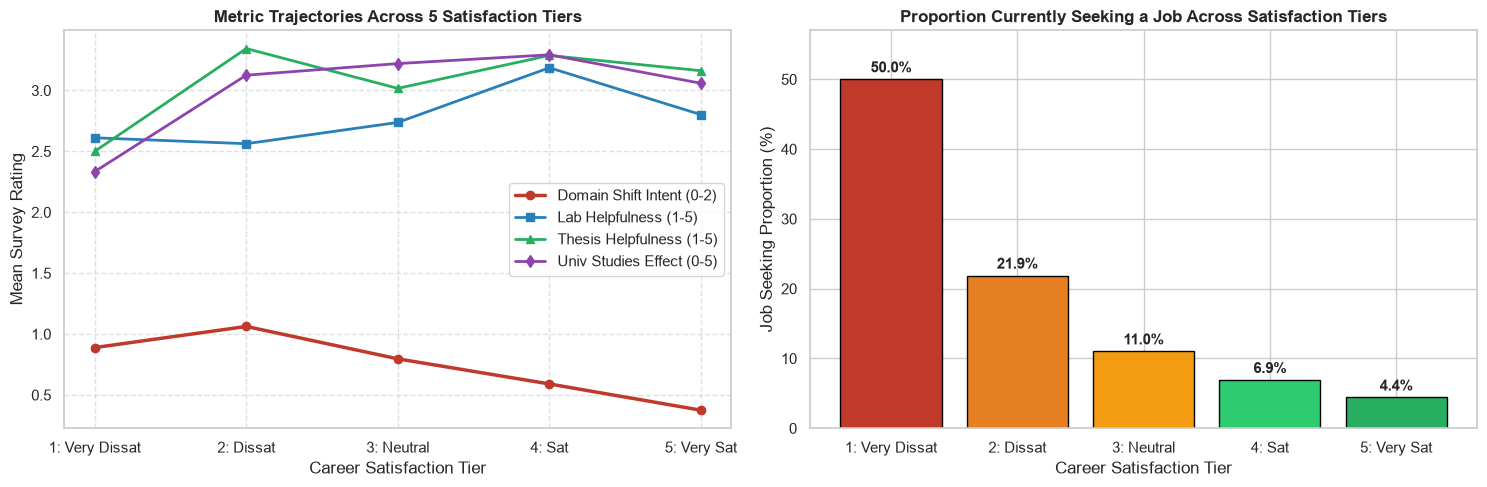

In [20]:
# Visualizing trends across all 5 Satisfaction Levels for top associated features
sat_levels = [1, 2, 3, 4, 5]
sat_names = ['1: Very Dissat', '2: Dissat', '3: Neutral', '4: Sat', '5: Very Sat']

trend_summary = []
for s in sat_levels:
    sub = df_assoc[df_assoc['Satisfaction_Num'] == s]
    trend_summary.append({
        'Satisfaction Level': s,
        'Domain Shift Intent (0-2)': sub['Shift_Intent_Num'].mean(),
        'Lab Courses Help (1-5)': pd.to_numeric(sub['Help_Lab'], errors='coerce').mean(),
        'Thesis Help (1-5)': pd.to_numeric(sub['Help_Thesis_Group_Work'], errors='coerce').mean(),
        'Univ Studies Effect (0-5)': pd.to_numeric(sub['University_Studies_Effect'], errors='coerce').mean(),
        'Job Seeking Rate (%)': (sub['Professional_Status'] == 'Currently seeking a job').mean() * 100
    })
trend_df = pd.DataFrame(trend_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Academic & Retention Mean Trajectory across Satisfaction Tiers
axes[0].plot(sat_names, trend_df['Domain Shift Intent (0-2)'], marker='o', linewidth=2.5, color='#c0392b', label='Domain Shift Intent (0-2)')
axes[0].plot(sat_names, trend_df['Lab Courses Help (1-5)'], marker='s', linewidth=2, color='#2980b9', label='Lab Helpfulness (1-5)')
axes[0].plot(sat_names, trend_df['Thesis Help (1-5)'], marker='^', linewidth=2, color='#27ae60', label='Thesis Helpfulness (1-5)')
axes[0].plot(sat_names, trend_df['Univ Studies Effect (0-5)'], marker='d', linewidth=2, color='#8e44ad', label='Univ Studies Effect (0-5)')
axes[0].set_title('Metric Trajectories Across 5 Satisfaction Tiers', fontweight='bold')
axes[0].set_ylabel('Mean Survey Rating')
axes[0].set_xlabel('Career Satisfaction Tier')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot B: Unemployment / Job-Seeking Rate Disparity Across Tiers
bar_colors = ['#c0392b', '#e67e22', '#f39c12', '#2ecc71', '#27ae60']
axes[1].bar(sat_names, trend_df['Job Seeking Rate (%)'], color=bar_colors, edgecolor='black')
axes[1].set_title('Proportion Currently Seeking a Job Across Satisfaction Tiers', fontweight='bold')
axes[1].set_ylabel('Job Seeking Proportion (%)')
axes[1].set_xlabel('Career Satisfaction Tier')
for i, val in enumerate(trend_df['Job Seeking Rate (%)']):
    axes[1].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
axes[1].set_ylim(0, max(trend_df['Job Seeking Rate (%)']) + 7)

plt.tight_layout()
plt.show()

## 4.3 Comprehensive Correlation Analysis Among Relevant Survey Features
To address **Requirement (3)**, we conduct a bivariate correlation analysis across all legitimate survey dimensions.

> [!IMPORTANT]
> **Methodological Rationale for Metric Choice:**
> - **Primary Metric (Spearman Rank Correlation):** Survey responses consist almost exclusively of ordinal Likert scales (1–5 ratings) and ordered ranks. Spearman correlation assesses monotonic relationships without assuming linear intervals or normality.
> - **Supplementary Metric (Pearson r):** Included for completeness to measure linear co-variance.
> - **Clean Exclusion of Categorical Data:** Nominal features lacking natural order (e.g. `University_Name`, `Professional_Status`, `Current_Career_Domain`) are strictly excluded from numeric correlation to prevent artificial numerical distortions.

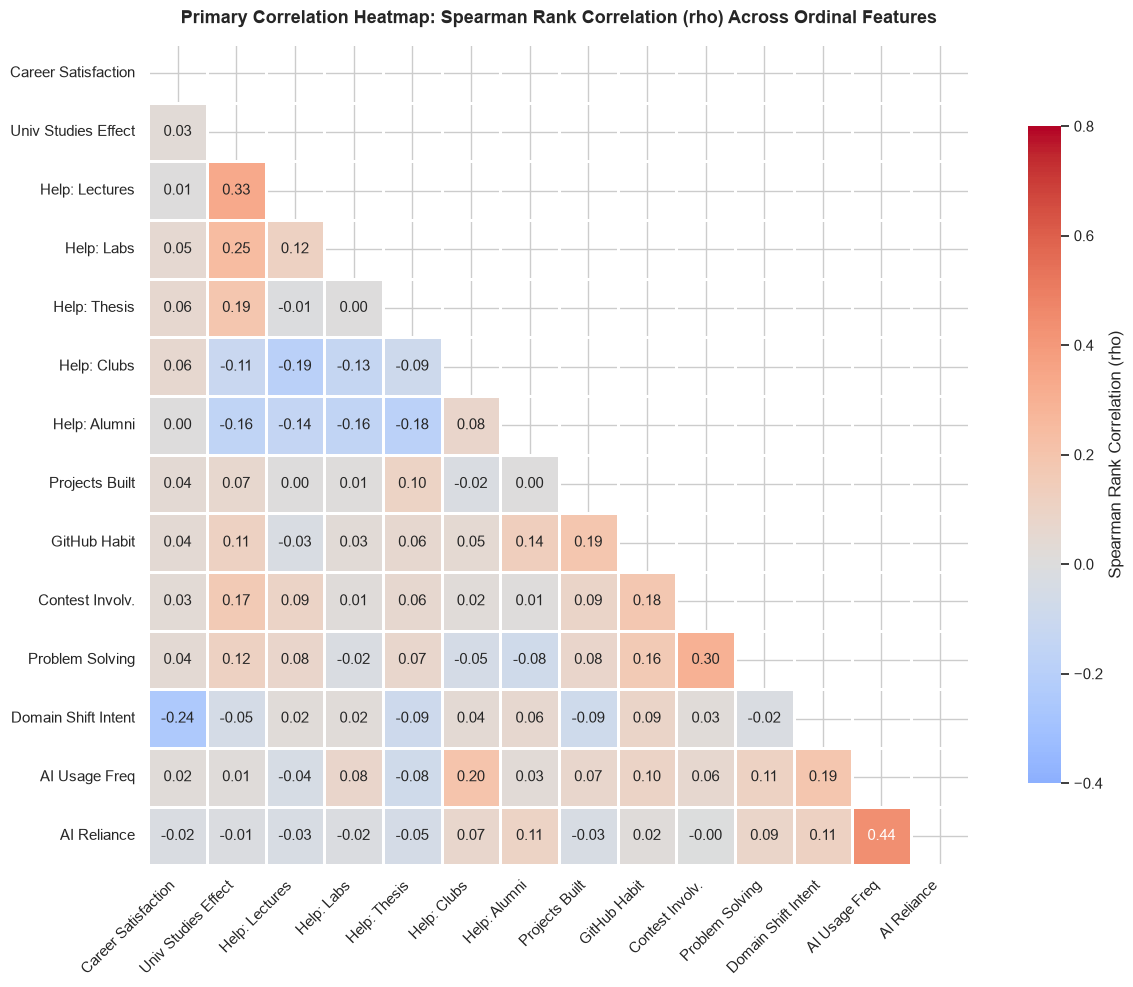

In [21]:
# Construct valid numerical/ordinal correlation dataset
corr_feature_cols = [
    'Satisfaction_Num', 'University_Studies_Effect', 'Help_Lecture', 'Help_Lab',
    'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network',
    'Projects_Num', 'GitHub_Num', 'Contest_Num', 'Problem_Solving_Ability',
    'Shift_Intent_Num', 'AI_Freq_Num', 'AI_Programming_Reliance'
]
corr_feature_names = [
    'Career Satisfaction', 'Univ Studies Effect', 'Help: Lectures', 'Help: Labs',
    'Help: Thesis', 'Help: Clubs', 'Help: Alumni', 'Projects Built',
    'GitHub Habit', 'Contest Involv.', 'Problem Solving',
    'Domain Shift Intent', 'AI Usage Freq', 'AI Reliance'
]

corr_data = df_assoc[corr_feature_cols].apply(pd.to_numeric, errors='coerce')
corr_data.columns = corr_feature_names

# Compute primary Spearman rank correlation
spearman_corr_mat = corr_data.corr(method='spearman')

# Compute supplementary Pearson correlation
pearson_corr_mat = corr_data.corr(method='pearson')

# Visualization: Primary Spearman Correlation Heatmap
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(spearman_corr_mat, dtype=bool))

sns.heatmap(spearman_corr_mat, mask=mask, cmap='coolwarm', vmin=-0.40, vmax=0.80, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.8,
            cbar_kws={"shrink": 0.8, "label": "Spearman Rank Correlation (rho)"})
plt.title('Primary Correlation Heatmap: Spearman Rank Correlation (rho) Across Ordinal Features',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== Top Synergy Clusters (Spearman Rank Correlation) ===


,Feature Pair,Spearman rho,Relationship Type
0,AI Reliance & AI Usage Freq,0.436,Strong Positive Synergy
1,Help: Lectures & Univ Studies Effect,0.334,Strong Positive Synergy
2,Problem Solving & Contest Involv.,0.297,Strong Positive Synergy
3,Help: Labs & Univ Studies Effect,0.248,Strong Positive Synergy
4,AI Usage Freq & Help: Clubs,0.200,Strong Positive Synergy
5,Help: Thesis & Univ Studies Effect,0.192,Strong Positive Synergy
6,AI Usage Freq & Domain Shift Intent,0.188,Strong Positive Synergy
7,GitHub Habit & Projects Built,0.187,Strong Positive Synergy
8,Domain Shift Intent & Career Satisfaction,-0.243,Inverse Association
9,Help: Clubs & Help: Lectures,-0.188,Inverse Association


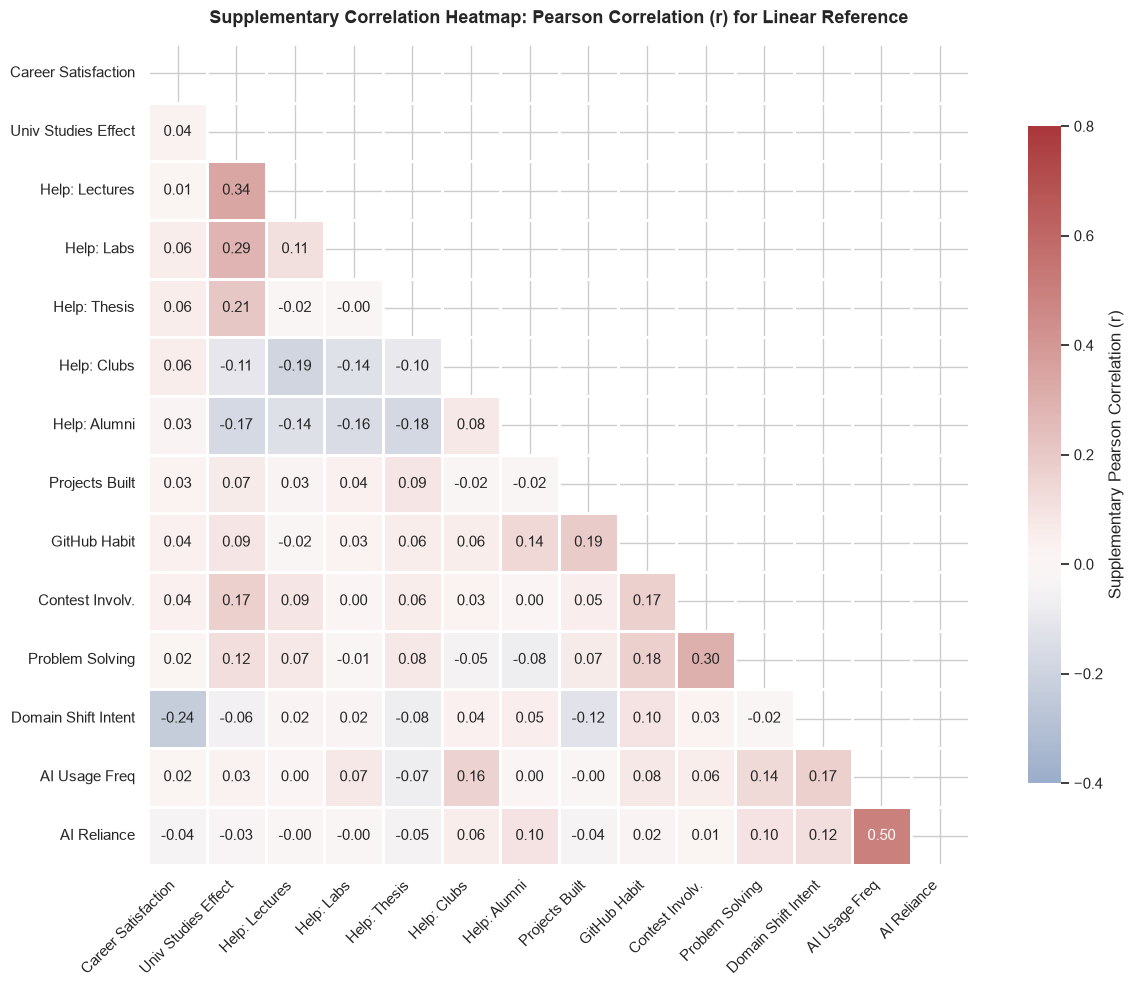

In [22]:
# Extraction and interpretation of key correlation clusters
# Find top non-diagonal positive and negative correlation pairs
upper_tri = spearman_corr_mat.where(np.triu(np.ones(spearman_corr_mat.shape), k=1).astype(bool))
unstacked_corr = upper_tri.unstack().dropna()
top_positive = unstacked_corr.sort_values(ascending=False).head(8)
top_negative = unstacked_corr.sort_values().head(5)

corr_summary_df = pd.DataFrame({
    'Feature Pair': [f"{idx[0]} & {idx[1]}" for idx in top_positive.index],
    'Spearman rho': top_positive.values.round(3),
    'Relationship Type': 'Strong Positive Synergy'
})
neg_summary_df = pd.DataFrame({
    'Feature Pair': [f"{idx[0]} & {idx[1]}" for idx in top_negative.index],
    'Spearman rho': top_negative.values.round(3),
    'Relationship Type': 'Inverse Association'
})

print("=== Top Synergy Clusters (Spearman Rank Correlation) ===")
display(pd.concat([corr_summary_df, neg_summary_df]).reset_index(drop=True))

# Supplementary Pearson Correlation Heatmap for linear reference
plt.figure(figsize=(13, 10))
sns.heatmap(pearson_corr_mat, mask=mask, cmap='vlag', vmin=-0.40, vmax=0.80, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.8,
            cbar_kws={"shrink": 0.8, "label": "Supplementary Pearson Correlation (r)"})
plt.title('Supplementary Correlation Heatmap: Pearson Correlation (r) for Linear Reference',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4.4 Potential Deficiencies and Factors Associated with Lower Satisfaction
To address **Requirement (4)**, we conduct a targeted gap analysis to identify specific factors and areas where low-satisfaction graduates report lower scores or higher friction.

> [!IMPORTANT]
> **Cautionary Note on Interpretation:**
> While we quantify differences between low-satisfaction and satisfied graduates, an observed deficiency (such as lower perceived lab course helpfulness or higher job-seeking rates) indicates an **empirical association**, not direct proof of a single root cause. We frame these insights as **potential deficiencies and factors associated with lower satisfaction** to guide institutional interventions.

=== Potential Deficiencies Gap Analysis: Low Sat (N=50) vs High Sat (N=324) & Level 5 (N=136) ===


,Factor / Dimension,Low Sat (1-2) Mean,High Sat (4-5) Mean,Diff (Low - High),Relative Gap (%),Level 5 Mean,Diff (Low - Lvl5)
0,Domain Shift Intent (0-2),1.00,0.50,0.50,100.0,0.38,0.62
1,Laboratory Helpfulness (1-5),2.58,3.02,-0.44,-14.7,2.80,-0.22
2,Univ Studies Overall Effect (0-5),2.84,3.19,-0.35,-11.1,3.06,-0.22
3,Alumni Network Helpfulness (1-5),2.66,2.93,-0.27,-9.3,2.86,-0.20
4,Thesis Helpfulness (1-5),3.04,3.23,-0.19,-6.0,3.16,-0.12
5,Lecture Helpfulness (1-5),2.70,2.85,-0.15,-5.2,2.88,-0.18
6,Club Activities Helpfulness (1-5),2.60,2.73,-0.13,-4.7,2.88,-0.27
7,Problem Solving Self-Rating (1-5),3.56,3.43,0.13,3.9,3.41,0.15
8,Projects Built (0-5),4.38,4.50,-0.12,-2.7,4.42,-0.04


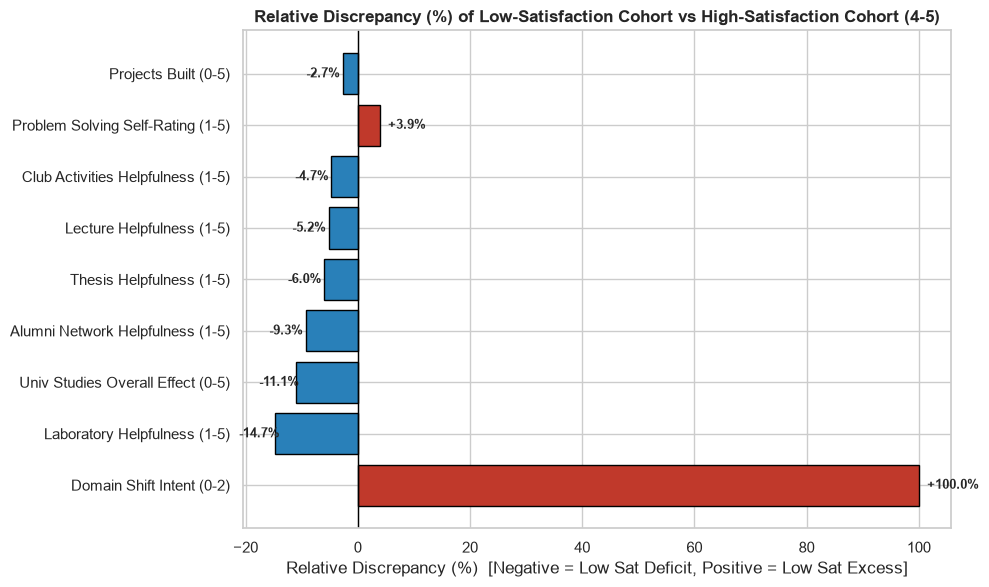

In [23]:
# Quantitative gap analysis: Low Satisfaction (1-2) vs High Satisfaction (4-5)
high_sat_mask = df_assoc['Satisfaction_Num'].isin([4, 5])
sat_5_mask = df_assoc['Satisfaction_Num'] == 5

low_cohort = df_assoc[low_sat_mask]
high_cohort = df_assoc[high_sat_mask]
sat5_cohort = df_assoc[sat_5_mask]

n_high = len(high_cohort)
n_sat5 = len(sat5_cohort)

gap_features = [
    ('Domain Shift Intent (0-2)', 'Shift_Intent_Num'),
    ('Laboratory Helpfulness (1-5)', 'Help_Lab'),
    ('Univ Studies Overall Effect (0-5)', 'University_Studies_Effect'),
    ('Alumni Network Helpfulness (1-5)', 'Help_Alumni_Network'),
    ('Thesis Helpfulness (1-5)', 'Help_Thesis_Group_Work'),
    ('Lecture Helpfulness (1-5)', 'Help_Lecture'),
    ('Club Activities Helpfulness (1-5)', 'Help_Club_Activities'),
    ('Problem Solving Self-Rating (1-5)', 'Problem_Solving_Ability'),
    ('Projects Built (0-5)', 'Projects_Num')
]

gap_records = []
for label, col in gap_features:
    m_low = pd.to_numeric(low_cohort[col], errors='coerce').mean()
    m_high = pd.to_numeric(high_cohort[col], errors='coerce').mean()
    m_sat5 = pd.to_numeric(sat5_cohort[col], errors='coerce').mean()
    diff_high = m_low - m_high
    pct_gap_high = (diff_high / m_high) * 100 if m_high != 0 else 0
    diff_sat5 = m_low - m_sat5
    pct_gap_sat5 = (diff_sat5 / m_sat5) * 100 if m_sat5 != 0 else 0
    
    gap_records.append({
        'Factor / Dimension': label,
        'Low Sat (1-2) Mean': round(m_low, 2),
        'High Sat (4-5) Mean': round(m_high, 2),
        'Diff (Low - High)': round(diff_high, 2),
        'Relative Gap (%)': round(pct_gap_high, 1),
        'Level 5 Mean': round(m_sat5, 2),
        'Diff (Low - Lvl5)': round(diff_sat5, 2)
    })

gap_df = pd.DataFrame(gap_records)
print(f"=== Potential Deficiencies Gap Analysis: Low Sat (N={n_low}) vs High Sat (N={n_high}) & Level 5 (N={n_sat5}) ===")
display(gap_df)

# Diverging Bar Chart of Relative Gaps
plt.figure(figsize=(10, 6))
colors = ['#c0392b' if x > 0 else '#2980b9' for x in gap_df['Relative Gap (%)']]
bars = plt.barh(gap_df['Factor / Dimension'], gap_df['Relative Gap (%)'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Relative Discrepancy (%) of Low-Satisfaction Cohort vs High-Satisfaction Cohort (4-5)', fontweight='bold')
plt.xlabel('Relative Discrepancy (%)  [Negative = Low Sat Deficit, Positive = Low Sat Excess]')
for bar in bars:
    w = bar.get_width()
    offset = 1.5 if w >= 0 else -6.5
    plt.text(w + offset, bar.get_y() + bar.get_height()/2, f"{w:+.1f}%", va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

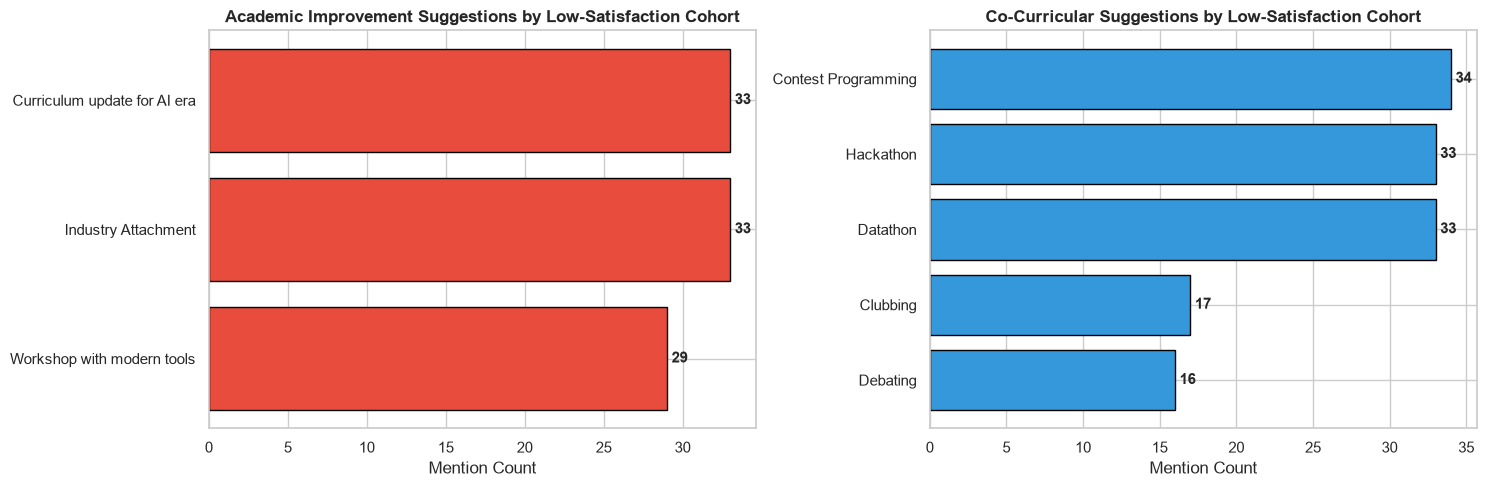

In [24]:
# Qualitative Suggestions Analysis: What specific improvements do low-satisfaction graduates advocate?
sugg_academic = low_cohort['Academic_Improvement_Suggestions'].dropna()
sugg_cocurr = low_cohort['CoCurricular_Job_Suggestions'].dropna()

# Extract individual multi-select items
from collections import Counter
acad_items = [item.strip() for line in sugg_academic for item in line.split(',') if item.strip()]
cocurr_items = [item.strip() for line in sugg_cocurr for item in line.split(',') if item.strip()]

top_acad_sugg = pd.Series(Counter(acad_items)).sort_values(ascending=True)
top_cocurr_sugg = pd.Series(Counter(cocurr_items)).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top_acad_sugg.index, top_acad_sugg.values, color='#e74c3c', edgecolor='black')
axes[0].set_title('Academic Improvement Suggestions by Low-Satisfaction Cohort', fontweight='bold')
axes[0].set_xlabel('Mention Count')
for i, v in enumerate(top_acad_sugg.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontweight='bold')

axes[1].barh(top_cocurr_sugg.index, top_cocurr_sugg.values, color='#3498db', edgecolor='black')
axes[1].set_title('Co-Curricular Suggestions by Low-Satisfaction Cohort', fontweight='bold')
axes[1].set_xlabel('Mention Count')
for i, v in enumerate(top_cocurr_sugg.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4.5 Statistical Comparison: Satisfaction Level 5 vs Low-Satisfaction Students Across Academic Dimensions
To address **Requirement (5)**, we conduct a rigorous statistical hypothesis testing benchmark comparing **Level 5 ('Very Satisfied')** graduates against **Low-Satisfaction (Ratings 1 & 2)** graduates across the five central university components:
1. **Lecture Courses** (`Help_Lecture`)
2. **Laboratory Courses** (`Help_Lab`)
3. **Thesis & Group Works** (`Help_Thesis_Group_Work`)
4. **Club Activities** (`Help_Club_Activities`)
5. **Alumni Network** (`Help_Alumni_Network`)

> [!IMPORTANT]
> **Statistical Design & Methodological Architecture:**
> - **Dynamic Cohort Sizing:** Sample sizes for Level 5 ($N_5$) and Low Satisfaction ($N_{\text{Low}}$) are dynamically resolved and verified directly from the dataset.
> - **Primary Non-Parametric Test (Mann-Whitney U):** Because survey responses are ordinal Likert rankings (1 to 5), the non-parametric Mann-Whitney U test (Wilcoxon rank-sum test) serves as the primary statistical test. We report the exact U-statistic, two-sided raw p-value (`p_raw`), and non-parametric effect size via **Rank-Biserial Correlation** ($r = 1 - \frac{2U}{n_1 n_2}$).
> - **Supplementary Parametric Test:** Welch's two-sample t-test (accounting for unequal variances) and Cohen's d are reported alongside for supplementary completeness.
> - **Multiple-Testing Correction:** We apply the **Benjamini-Hochberg (BH) procedure** across the 5 simultaneous tests to control the False Discovery Rate (`p_adj_fdr`).

In [25]:
# Dynamic extraction and sample size verification
sat5_mask = df_assoc['Satisfaction_Num'] == 5
low_sat_mask = df_assoc['Satisfaction_Num'].isin([1, 2])

group_sat5 = df_assoc[sat5_mask]
group_low = df_assoc[low_sat_mask]

n_5 = len(group_sat5)
n_low = len(group_low)
print(f"Verified Cohort Sizes: Level 5 (Very Satisfied): N = {n_5} | Low Satisfaction (Ratings 1 & 2): N = {n_low}")

acad_benchmark_dims = [
    ('Help_Lecture', 'Lecture Courses'),
    ('Help_Lab', 'Laboratory Courses'),
    ('Help_Thesis_Group_Work', 'Thesis & Group Works'),
    ('Help_Club_Activities', 'Club Activities'),
    ('Help_Alumni_Network', 'Alumni Network')
]

comp_records = []
p_raw_comp = []

for col, name in acad_benchmark_dims:
    s5 = pd.to_numeric(group_sat5[col], errors='coerce').dropna()
    slow = pd.to_numeric(group_low[col], errors='coerce').dropna()
    
    # 1. Primary: Two-sided Mann-Whitney U test
    u_stat, u_p = stats.mannwhitneyu(s5, slow, alternative='two-sided')
    p_raw_comp.append(u_p)
    
    # Rank-biserial correlation
    n1, n2 = len(s5), len(slow)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    
    # 2. Supplementary: Welch's t-test and Cohen's d
    t_stat, t_p = stats.ttest_ind(s5, slow, equal_var=False)
    s1, s2 = np.std(s5, ddof=1), np.std(slow, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    cohen_d = (s5.mean() - slow.mean()) / pooled_sd if pooled_sd != 0 else 0
    
    comp_records.append({
        'Academic Dimension': name,
        'Level 5 Mean +/- SD': f"{s5.mean():.2f} +/- {s1:.2f}",
        'Level 5 Median [IQR]': f"{s5.median():.1f} [{s5.quantile(0.75)-s5.quantile(0.25):.1f}]",
        'Low Sat Mean +/- SD': f"{slow.mean():.2f} +/- {s2:.2f}",
        'Low Sat Median [IQR]': f"{slow.median():.1f} [{slow.quantile(0.75)-slow.quantile(0.25):.1f}]",
        'Diff (Lvl5 - Low)': f"{s5.mean() - slow.mean():+.2f}",
        'Mann-Whitney U': round(u_stat, 1),
        'p_raw (MWU)': u_p,
        'Rank-Biserial r': round(rank_biserial, 3),
        'Welch t (suppl)': round(t_stat, 2),
        'Cohen d (suppl)': round(cohen_d, 2)
    })

# Benjamini-Hochberg FDR correction across the 5 dimensions
p_adj_comp = stats.false_discovery_control(p_raw_comp, method='bh')
for i, p_adj in enumerate(p_adj_comp):
    comp_records[i]['p_adj_fdr'] = p_adj
    comp_records[i]['FDR Sig'] = '***' if p_adj < 0.001 else ('**' if p_adj < 0.01 else ('*' if p_adj < 0.05 else 'ns'))

comp_table = pd.DataFrame(comp_records)
display_comp = comp_table[['Academic Dimension', 'Level 5 Mean +/- SD', 'Level 5 Median [IQR]',
                          'Low Sat Mean +/- SD', 'Low Sat Median [IQR]', 'Diff (Lvl5 - Low)',
                          'Mann-Whitney U', 'p_raw (MWU)', 'p_adj_fdr', 'Rank-Biserial r',
                          'Welch t (suppl)', 'Cohen d (suppl)', 'FDR Sig']].copy()
display_comp['p_raw (MWU)'] = display_comp['p_raw (MWU)'].apply(lambda x: f"{x:.4f}")
display_comp['p_adj_fdr'] = display_comp['p_adj_fdr'].apply(lambda x: f"{x:.4f}")

print("=== Comprehensive Statistical Diagnostic Table: Satisfaction Level 5 vs Low Satisfaction ===")
print("Primary Evidence: Mann-Whitney U test (non-parametric) with Benjamini-Hochberg FDR correction.")
display(display_comp)

Verified Cohort Sizes: Level 5 (Very Satisfied): N = 136 | Low Satisfaction (Ratings 1 & 2): N = 50
=== Comprehensive Statistical Diagnostic Table: Satisfaction Level 5 vs Low Satisfaction ===
Primary Evidence: Mann-Whitney U test (non-parametric) with Benjamini-Hochberg FDR correction.


,Academic Dimension,Level 5 Mean +/- SD,Level 5 Median [IQR],Low Sat Mean +/- SD,Low Sat Median [IQR],Diff (Lvl5 - Low),Mann-Whitney U,p_raw (MWU),p_adj_fdr,Rank-Biserial r,Welch t (suppl),Cohen d (suppl),FDR Sig
0,Lecture Courses,2.88 +/- 1.45,3.0 [2.2],2.70 +/- 1.54,2.0 [3.0],+0.18,3654.0,0.4252,0.4994,-0.075,0.73,0.12,ns
1,Laboratory Courses,2.80 +/- 1.38,3.0 [2.0],2.58 +/- 1.46,2.0 [3.0],+0.22,3730.0,0.3000,0.4994,-0.097,0.93,0.16,ns
2,Thesis & Group Works,3.16 +/- 1.41,3.0 [2.0],3.04 +/- 1.23,3.0 [2.0],+0.12,3615.5,0.4994,0.4994,-0.063,0.58,0.09,ns
3,Club Activities,2.88 +/- 1.47,3.0 [2.2],2.60 +/- 1.44,3.0 [2.8],+0.27,3763.5,0.2530,0.4994,-0.107,1.15,0.19,ns
4,Alumni Network,2.86 +/- 1.52,3.0 [3.0],2.66 +/- 1.42,2.0 [3.0],+0.20,3646.5,0.4393,0.4994,-0.073,0.84,0.13,ns


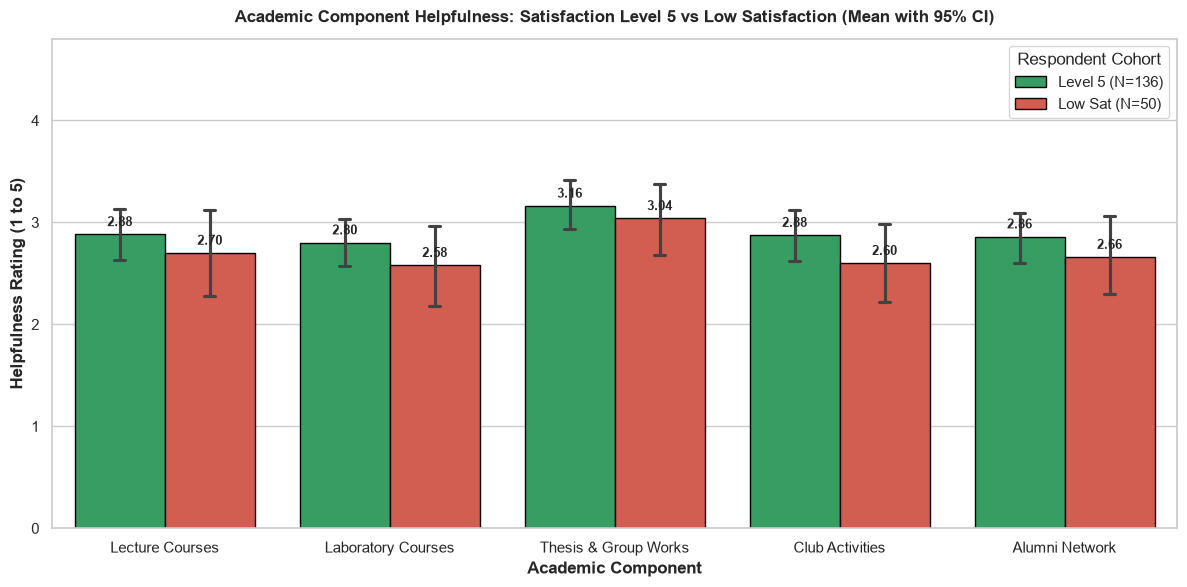

In [26]:
# Visualization 1: Grouped Mean Comparison with 95% Confidence Intervals & Annotations
vis_summary = []
for col, name in acad_benchmark_dims:
    s5_vals = pd.to_numeric(group_sat5[col], errors='coerce').dropna()
    low_vals = pd.to_numeric(group_low[col], errors='coerce').dropna()
    for v in s5_vals:
        vis_summary.append({'Dimension': name, 'Rating': v, 'Group': f'Level 5 (N={n_5})'})
    for v in low_vals:
        vis_summary.append({'Dimension': name, 'Rating': v, 'Group': f'Low Sat (N={n_low})'})
vis_df = pd.DataFrame(vis_summary)

plt.figure(figsize=(12, 6))
actual_palette = {f'Level 5 (N={n_5})': '#27ae60', f'Low Sat (N={n_low})': '#e74c3c'}

ax = sns.barplot(data=vis_df, x='Dimension', y='Rating', hue='Group',
                 palette=actual_palette, errorbar=('ci', 95), capsize=0.1, edgecolor='black')

plt.title('Academic Component Helpfulness: Satisfaction Level 5 vs Low Satisfaction (Mean with 95% CI)',
          fontweight='bold', fontsize=12, pad=12)
plt.ylabel('Helpfulness Rating (1 to 5)', fontweight='bold')
plt.xlabel('Academic Component', fontweight='bold')
plt.ylim(0, 4.8)
plt.legend(title='Respondent Cohort', loc='upper right')

# Annotate bars with means
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=4, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

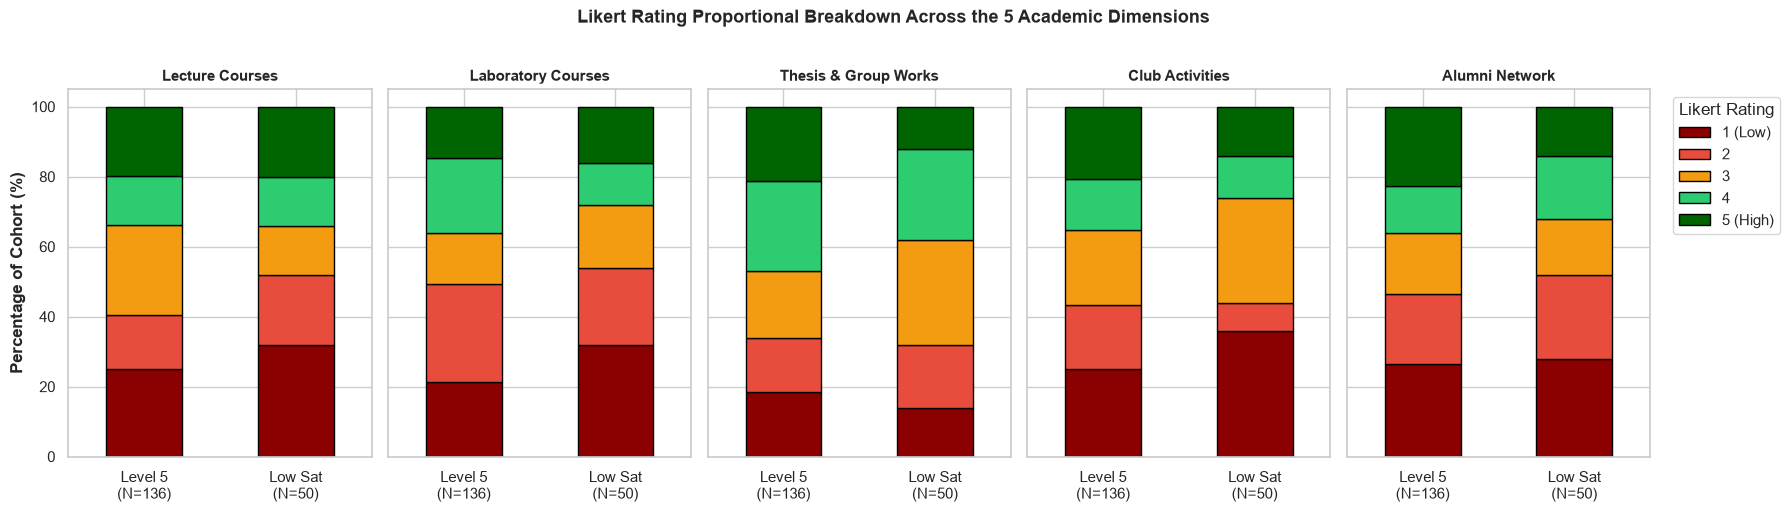

In [27]:
# Visualization 2: 100% Proportional Likert Distribution Breakdown (Ratings 1 to 5)
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
likert_palette = ['#8b0000', '#e74c3c', '#f39c12', '#2ecc71', '#006400']

for i, (col, name) in enumerate(acad_benchmark_dims):
    s5_counts = pd.to_numeric(group_sat5[col], errors='coerce').value_counts(normalize=True).sort_index() * 100
    low_counts = pd.to_numeric(group_low[col], errors='coerce').value_counts(normalize=True).sort_index() * 100
    
    dist_df = pd.DataFrame({
        f'Level 5\n(N={n_5})': s5_counts,
        f'Low Sat\n(N={n_low})': low_counts
    }).reindex([1.0, 2.0, 3.0, 4.0, 5.0], fill_value=0).T
    
    dist_df.plot(kind='bar', stacked=True, ax=axes[i], color=likert_palette, edgecolor='black', legend=(i == 4))
    axes[i].set_title(name, fontweight='bold', fontsize=11)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    if i == 0:
        axes[i].set_ylabel('Percentage of Cohort (%)', fontweight='bold')

if axes[4].get_legend():
    axes[4].legend(title='Likert Rating', labels=['1 (Low)', '2', '3', '4', '5 (High)'],
                   bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Likert Rating Proportional Breakdown Across the 5 Academic Dimensions', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

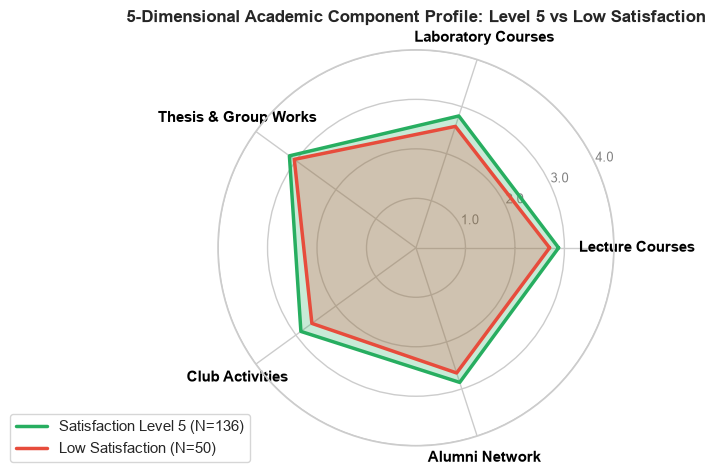

In [28]:
# Visualization 3: 5-Dimensional Academic Helpfulness Radar / Spider Chart
categories = [name for _, name in acad_benchmark_dims]
N = len(categories)

mean_s5 = [pd.to_numeric(group_sat5[col], errors='coerce').mean() for col, _ in acad_benchmark_dims]
mean_low = [pd.to_numeric(group_low[col], errors='coerce').mean() for col, _ in acad_benchmark_dims]

# Complete the circular polygon
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
mean_s5_plot = mean_s5 + mean_s5[:1]
mean_low_plot = mean_low + mean_low[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], categories, color='black', size=11, fontweight='bold')
ax.set_rlabel_position(25)
plt.yticks([1, 2, 3, 4], ["1.0", "2.0", "3.0", "4.0"], color="grey", size=9)
plt.ylim(0, 4.0)

# Plot Level 5 polygon
ax.plot(angles, mean_s5_plot, linewidth=2.5, linestyle='solid', color='#27ae60', label=f'Satisfaction Level 5 (N={n_5})')
ax.fill(angles, mean_s5_plot, color='#27ae60', alpha=0.25)

# Plot Low Satisfaction polygon
ax.plot(angles, mean_low_plot, linewidth=2.5, linestyle='solid', color='#e74c3c', label=f'Low Satisfaction (N={n_low})')
ax.fill(angles, mean_low_plot, color='#e74c3c', alpha=0.25)

plt.title('5-Dimensional Academic Component Profile: Level 5 vs Low Satisfaction', fontweight='bold', size=12, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.show()

## 5. Detailed Step-by-Step Feature Preprocessing & Engineering

### 5.1 Column Exclusion Audit
The following raw columns are systematically excluded:
1. **`Timestamp` (Col 0)**: Metadata timestamp with no causal relationship to career satisfaction.
2. **`1. University Name` (Col 1)**: 28 institutions with severe sample imbalance (KUET & BUET comprise 46%, while 16 universities have only 1–2 responses). Including this causes tree memorization and poor external generalization.
3. **`16. If yes, target domain` (Col 20)**: Excluded due to >62% missingness and conditional leakage.
4. **`20 & 21. Academic & Co-curricular Suggestions` (Cols 24 & 25)**: Unstructured free-text policy feedback.

---

### 5.2 Engineering Temporal & Experience Features
- **`Years_Since_Grad`**: Computed as $2026 - 	ext{Graduation\_Year}$ (captures career experience from 0 to 9 years).

---

### 5.3 Career Domain Pivots
- **`Domain_Switched`**: Computed as $1$ if $	ext{First\_Domain} \neq \text{Current\_Domain}$, else $0$ (captures horizontal transitions).
- **`Current_Domain`**: Imputed with `'Not Applicable'` for missing values, kept for one-hot encoding.

---

### 5.4 Future Domain Shift Intent (Col 19)
- **`Domain_Shift_Intent`**: Monotonically mapped:
  $$\text{'No'} \rightarrow 0,\quad \text{'Maybe'} \rightarrow 1,\quad \text{'Yes'} \rightarrow 2$$

---

### 5.5 Preserving Distinct Academic Helpfulness Features (Cols 4–9)
We preserve all 6 distinct components individually (missing values imputed with neutral rating 3):
- `Univ_Studies_Effect` (Col 4: 0 to 5)
- `Help_Lecture` (Col 5: 1 to 5)
- `Help_Lab` (Col 6: 1 to 5)
- `Help_Thesis` (Col 7: 1 to 5)
- `Help_Club` (Col 8: 1 to 5)
- `Help_Alumni` (Col 9: 1 to 5)

---

### 5.6 Technical, Competitive & Extracurricular Habits (Cols 10–15)
- `Club_Count` (Col 10): Count of multi-select club activities (0 to 5).
- `Internship_Exp` (Col 11): Binary mapped (`'Yes'` $\rightarrow 1$, `'No'` $\rightarrow 0$).
- `Projects_Built` (Col 12): Mapped `'0'` $\rightarrow 0$, $\dots$, `'5 or more'` $\rightarrow 5$.
- `GitHub_Habit` (Col 13): Mapped `'Rarely used'` $\rightarrow 0$, `'Occasionally'` $\rightarrow 1$, `'Actively'` $\rightarrow 2$.
- `Contest_Involvement` (Col 14): Mapped `'Never'` $\rightarrow 0$, `'Occasionally'` $\rightarrow 1$, `'Regularly'` $\rightarrow 2$, `'Competitively'` $\rightarrow 3$.
- `Problem_Solving` (Col 15): Retained as numeric scale (1 to 5).

---

### 5.7 AI Perceptions & Readiness (Cols 21–23)
- `AI_Usage_Freq` (Col 21): Mapped `'Never'` $\rightarrow 0$, `'Rarely'` $\rightarrow 1$, `'Weekly'` $\rightarrow 2$, `'Constantly'` $\rightarrow 3$.
- `AI_Concerns_Opinion` (Col 22): Categorical mapped to `{'Positive', 'Neutral', 'Concerned'}`.
- `AI_Reliance` (Col 23): Retained as numeric scale (1 to 5).

In [29]:
# Step 5.2: Temporal Feature Engineering
years_since_grad = 2026 - df.iloc[:, 2]

# Step 5.3: Career Domain Transitions
first_dom = df.iloc[:, 16].fillna('Not Applicable')
curr_dom = df.iloc[:, 17].fillna('Not Applicable')
domain_switched = (first_dom != curr_dom).astype(int)

# Step 5.4: Domain Shift Intent (Col 19)
shift_intent_map = {'No': 0, 'Maybe': 1, 'Yes': 2}
domain_shift_intent = df.iloc[:, 19].map(shift_intent_map).fillna(1)

# Step 5.5: Academic Helpfulness Distinct Sub-Dimensions
univ_effect = pd.to_numeric(df.iloc[:, 4], errors='coerce').fillna(3)
help_lecture = pd.to_numeric(df.iloc[:, 5], errors='coerce').fillna(3)
help_lab = pd.to_numeric(df.iloc[:, 6], errors='coerce').fillna(3)
help_thesis = pd.to_numeric(df.iloc[:, 7], errors='coerce').fillna(3)
help_club = pd.to_numeric(df.iloc[:, 8], errors='coerce').fillna(3)
help_alumni = pd.to_numeric(df.iloc[:, 9], errors='coerce').fillna(3)

# Step 5.6: Technical & Extracurricular Habits
club_counts = df.iloc[:, 10].fillna('').apply(lambda x: len([c for c in str(x).split(',') if c.strip()]) if x else 0)
proj_map = {'0': 0, 0: 0, 1: 1, '1': 1, 2: 2, '2': 2, 3: 3, '3': 3, 4: 4, '4': 4, '5 or more': 5}
gh_map = {'Rarely used': 0, 'Occasionally maintained': 1, 'Actively maintained': 2}
contest_map = {'Never': 0, 'Occasionally': 1, 'Regularly': 2, 'Competitively': 3}

projects_num = df.iloc[:, 12].map(proj_map).fillna(2)
github_num = df.iloc[:, 13].map(gh_map).fillna(1)
contest_num = df.iloc[:, 14].map(contest_map).fillna(0)
ps_num = pd.to_numeric(df.iloc[:, 15], errors='coerce').fillna(3)
internship_bin = df.iloc[:, 11].map({'Yes': 1, 'No': 0}).fillna(0)

# Step 5.7: AI Perceptions & Reliance
ai_freq_map = {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Frequently': 2, 'Constantly': 3, 'Daily': 3}
ai_opinion_map = {
    'Positive': 'Positive', 'Excited / Positive': 'Positive',
    'Neutral': 'Neutral', 'Neutral / Adaptable': 'Neutral',
    'Negative': 'Concerned', 'Anxious / Worried': 'Concerned', 'Threatened / Insecure': 'Concerned'
}

ai_usage_freq = df.iloc[:, 21].map(ai_freq_map).fillna(1)
ai_concerns = df.iloc[:, 22].map(ai_opinion_map).fillna('Neutral')
ai_reliance = pd.to_numeric(df.iloc[:, 23], errors='coerce').fillna(2)

# Step 5.8: Assemble Final Feature Matrix X
X = pd.DataFrame({
    'Years_Since_Grad': years_since_grad,
    'Professional_Status': df.iloc[:, 3].fillna('Employed'),
    'Univ_Studies_Effect': univ_effect,
    'Help_Lecture': help_lecture,
    'Help_Lab': help_lab,
    'Help_Thesis': help_thesis,
    'Help_Club': help_club,
    'Help_Alumni': help_alumni,
    'Club_Count': club_counts,
    'Internship_Exp': internship_bin,
    'Projects_Built': projects_num,
    'GitHub_Habit': github_num,
    'Contest_Involvement': contest_num,
    'Problem_Solving': ps_num,
    'Current_Domain': curr_dom,
    'Domain_Switched': domain_switched,
    'Domain_Shift_Intent': domain_shift_intent,
    'AI_Usage_Freq': ai_usage_freq,
    'AI_Concerns_Opinion': ai_concerns,
    'AI_Reliance': ai_reliance
})



y = df['Target_5Class']

# Distinguish numerical vs categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Final Engineered Feature Matrix: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Numeric Features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"Total Missing Values in Feature Matrix: {X.isnull().sum().sum()}")
display(X.head(3))

Final Engineered Feature Matrix: 492 samples, 20 features
Numeric Features (17): ['Years_Since_Grad', 'Univ_Studies_Effect', 'Help_Lecture', 'Help_Lab', 'Help_Thesis', 'Help_Club', 'Help_Alumni', 'Club_Count', 'Internship_Exp', 'Projects_Built', 'GitHub_Habit', 'Contest_Involvement', 'Problem_Solving', 'Domain_Switched', 'Domain_Shift_Intent', 'AI_Usage_Freq', 'AI_Reliance']
Categorical Features (3): ['Professional_Status', 'Current_Domain', 'AI_Concerns_Opinion']
Total Missing Values in Feature Matrix: 0


,Years_Since_Grad,Professional_Status,Univ_Studies_Effect,Help_Lecture,Help_Lab,Help_Thesis,Help_Club,Help_Alumni,Club_Count,Internship_Exp,Projects_Built,GitHub_Habit,Contest_Involvement,Problem_Solving,Current_Domain,Domain_Switched,Domain_Shift_Intent,AI_Usage_Freq,AI_Concerns_Opinion,AI_Reliance
0,1,Higher studies,3,1,4,2,5,3,4,1,5,1,1,3,Data Science / ML / AI,0,0.0,3,Positive,2
1,2,Employed,3,5,3,1,4,2,3,1,5,2,2,5,Software Engineer,0,2.0,3,Positive,3
2,2,Employed,2,5,1,4,3,2,4,1,5,1,1,4,Networking / DevOps / Cloud,0,2.0,3,Neutral,3


## 6. Stratified Train/Test Split (80:20 Split) & Preprocessing Pipeline
- **Split Configuration**: **80% Training ($N = 393$)** and **20% Holdout Test ($N = 99$)** with exact class stratification.
- **Pipeline Scaling & Encoding**:
  - `StandardScaler()` applied to numerical attributes.
  - `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` applied to nominal attributes.
  - Transformers are fitted **strictly on the training partition** inside Scikit-Learn `Pipeline` objects to prevent data leakage.

In [30]:
# Step 6.1: Execute Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 6.2: Define ColumnTransformer Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print(f"Training Instances (80%): {len(X_train)}")
print(f"Holdout Test Instances (20%): {len(X_test)}")
print("\nClass Proportions in Training Split:")
print(y_train.value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

Training Instances (80%): 393
Holdout Test Instances (20%): 99

Class Proportions in Training Split:
Target_5Class
Satisfied            38.2%
Very Satisfied       27.7%
Neutral              23.9%
Dissatisfied          6.6%
Very Dissatisfied     3.6%
Name: proportion, dtype: str


## 7. 9 Machine Learning Classifiers & Explicit Hyperparameter Configurations

We benchmark the **9 requested Supervised Classification Models**:

| # | Model Name | Hyperparameters & Configuration | Algorithmic Rationale & Role |
| :-: | :--- | :--- | :--- |
| 1 | **Decision Tree** | `max_depth=4, min_samples_leaf=5, criterion='gini', random_state=42` | Pruned interpretable tree (mirroring WEKA J48) with minimal branch depth. |
| 2 | **Gradient Boosting** | `n_estimators=100, learning_rate=0.08, max_depth=3, subsample=0.9, random_state=42` | Sequential residual gradient boosting optimizing multi-class log-loss. |
| 3 | **$k$-Nearest Neighbors** | `n_neighbors=5, weights='distance', metric='minkowski'` | Distance-weighted instance neighbor voting ($k=5$). |
| 4 | **Logistic Regression** | `max_iter=1000, class_weight='balanced', C=1.0, solver='lbfgs', random_state=42` | Balanced L2 regularized multinomial linear baseline. |
| 5 | **Multi-Layer Perceptron** | `hidden_layer_sizes=(64, 32), max_iter=500, alpha=0.01, random_state=42` | Multi-layer feedforward artificial neural network with backpropagation. |
| 6 | **Naive Bayes (Gaussian)** | `var_smoothing=1e-9` | Probabilistic conditional feature independence baseline. |
| 7 | **Random Forest** | `n_estimators=150, max_depth=5, min_samples_split=4, class_weight='balanced', random_state=42` | Ensemble of 150 de-correlated trees with balanced class weighting. |
| 8 | **Ridge Classifier** | `alpha=1.0, class_weight='balanced', random_state=42` | L2 regularized least-squares linear classifier. |
| 9 | **Support Vector Machine** | `kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42` | Non-linear maximum-margin radial basis kernel classifier. |

In [31]:
# Step 7.1: Configure the 9 Classifiers with explicit hyperparameters
classifiers = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=4, 
        min_samples_leaf=5, 
        criterion='gini', 
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.08, 
        subsample=0.9, 
        random_state=42
    ),
    'k-Nearest Neighbors (k=5)': KNeighborsClassifier(
        n_neighbors=5, 
        weights='distance', 
        metric='minkowski'
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        C=1.0, 
        solver='lbfgs', 
        random_state=42
    ),
    'Multi-Layer Perceptron (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        max_iter=500, 
        alpha=0.01, 
        random_state=42
    ),
    'Naive Bayes (Gaussian)': GaussianNB(
        var_smoothing=1e-9
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, 
        max_depth=5, 
        min_samples_split=4, 
        class_weight='balanced', 
        random_state=42
    ),
    'Ridge Classifier': RidgeClassifier(
        alpha=1.0, 
        class_weight='balanced', 
        random_state=42
    ),
    'Support Vector Machine (RBF)': SVC(
        kernel='rbf', 
        C=1.0, 
        gamma='scale', 
        probability=True, 
        class_weight='balanced', 
        random_state=42
    )
}

print(f"Configured exactly {len(classifiers)} Machine Learning Classification Models for Benchmarking.")

Configured exactly 9 Machine Learning Classification Models for Benchmarking.


## 8. Model Training, 5-Fold Cross-Validation & 80:20 Holdout Testing
We execute **5-Fold Stratified Cross-Validation** on the training split ($N=393$) to measure out-of-fold generalization, followed by evaluation on the unseen holdout test set ($N=99$).

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained_models = {}

print("Benchmarking all 9 Classifiers across 5-Fold Stratified CV and 80:20 Holdout Test Set...")

for name, clf in classifiers.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # 5-Fold Cross Validation on Training Split
    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    )
    pipe.fit(X_train, y_train)
    y_test_pred = pipe.predict(X_test)
    
    trained_models[name] = pipe
    
    # Holdout Test Evaluation
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    results_list.append({
        'Model Name': name,
        'CV Accuracy (5-Fold)': f"{cv_scores['test_accuracy'].mean():.3f} ± {cv_scores['test_accuracy'].std():.3f}",
        'CV Macro F1 (5-Fold)': f"{cv_scores['test_f1_macro'].mean():.3f} ± {cv_scores['test_f1_macro'].std():.3f}",
        'Holdout Test Accuracy': f"{test_acc:.3f}",
        'Holdout Macro Precision': f"{test_prec:.3f}",
        'Holdout Macro Recall': f"{test_rec:.3f}",
        'Holdout Macro F1-Score': f"{test_f1:.3f}",
        '_raw_test_acc': test_acc,
        '_raw_test_f1': test_f1,
        '_raw_cv_acc': cv_scores['test_accuracy'].mean()
    })

benchmark_df = pd.DataFrame(results_list).sort_values(by='_raw_test_f1', ascending=False).reset_index(drop=True)

print("\n=== Comprehensive 9-Model Benchmark Summary Table ===")
display(benchmark_df.drop(columns=['_raw_test_acc', '_raw_test_f1', '_raw_cv_acc']))

Benchmarking all 9 Classifiers across 5-Fold Stratified CV and 80:20 Holdout Test Set...

=== Comprehensive 9-Model Benchmark Summary Table ===


,Model Name,CV Accuracy (5-Fold),CV Macro F1 (5-Fold),Holdout Test Accuracy,Holdout Macro Precision,Holdout Macro Recall,Holdout Macro F1-Score
0,Gradient Boosting,0.420 ± 0.057,0.337 ± 0.090,0.444,0.464,0.334,0.362
1,Multi-Layer Perceptron (MLP),0.392 ± 0.063,0.291 ± 0.079,0.394,0.297,0.292,0.289
2,Support Vector Machine (RBF),0.389 ± 0.029,0.306 ± 0.049,0.374,0.246,0.257,0.246
3,k-Nearest Neighbors (k=5),0.389 ± 0.026,0.262 ± 0.057,0.394,0.237,0.256,0.245
4,Ridge Classifier,0.257 ± 0.070,0.230 ± 0.054,0.273,0.241,0.226,0.217
5,Random Forest,0.364 ± 0.042,0.313 ± 0.062,0.323,0.235,0.229,0.216
6,Logistic Regression,0.265 ± 0.053,0.234 ± 0.047,0.263,0.231,0.224,0.212
7,Decision Tree,0.369 ± 0.034,0.253 ± 0.038,0.343,0.196,0.206,0.191
8,Naive Bayes (Gaussian),0.112 ± 0.025,0.105 ± 0.028,0.051,0.056,0.106,0.047


## 9. Comparative Visualizations & $5 \times 5$ Confusion Matrices
We visualize test set accuracy and macro F1 comparisons across all 9 models, along with $3 \times 3$ confusion matrices for top classifiers.

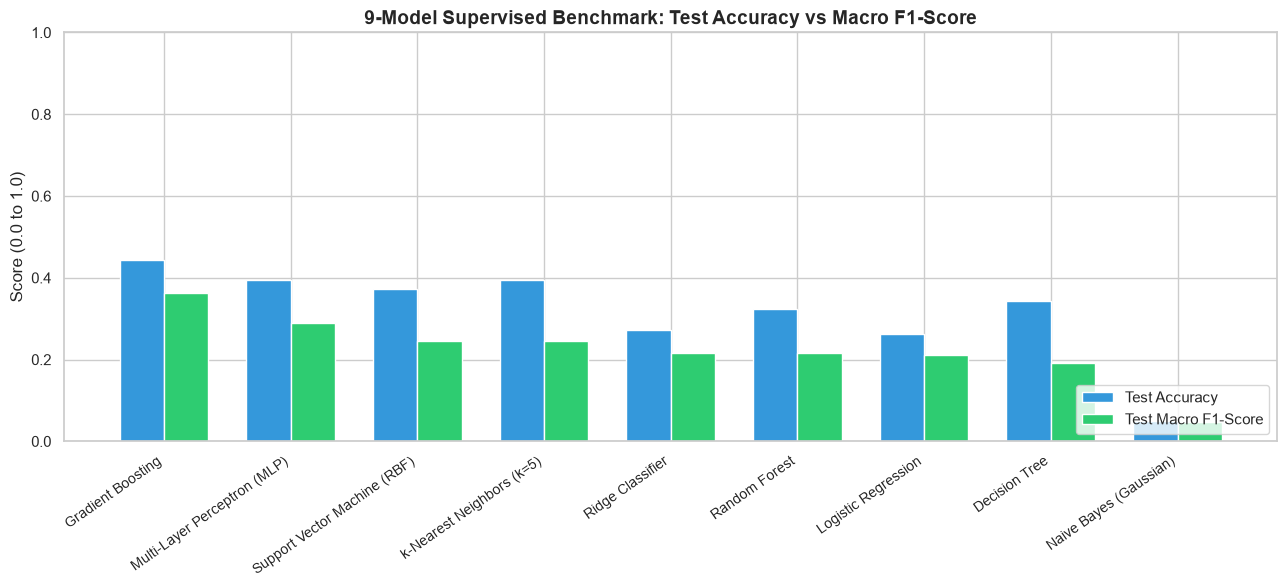

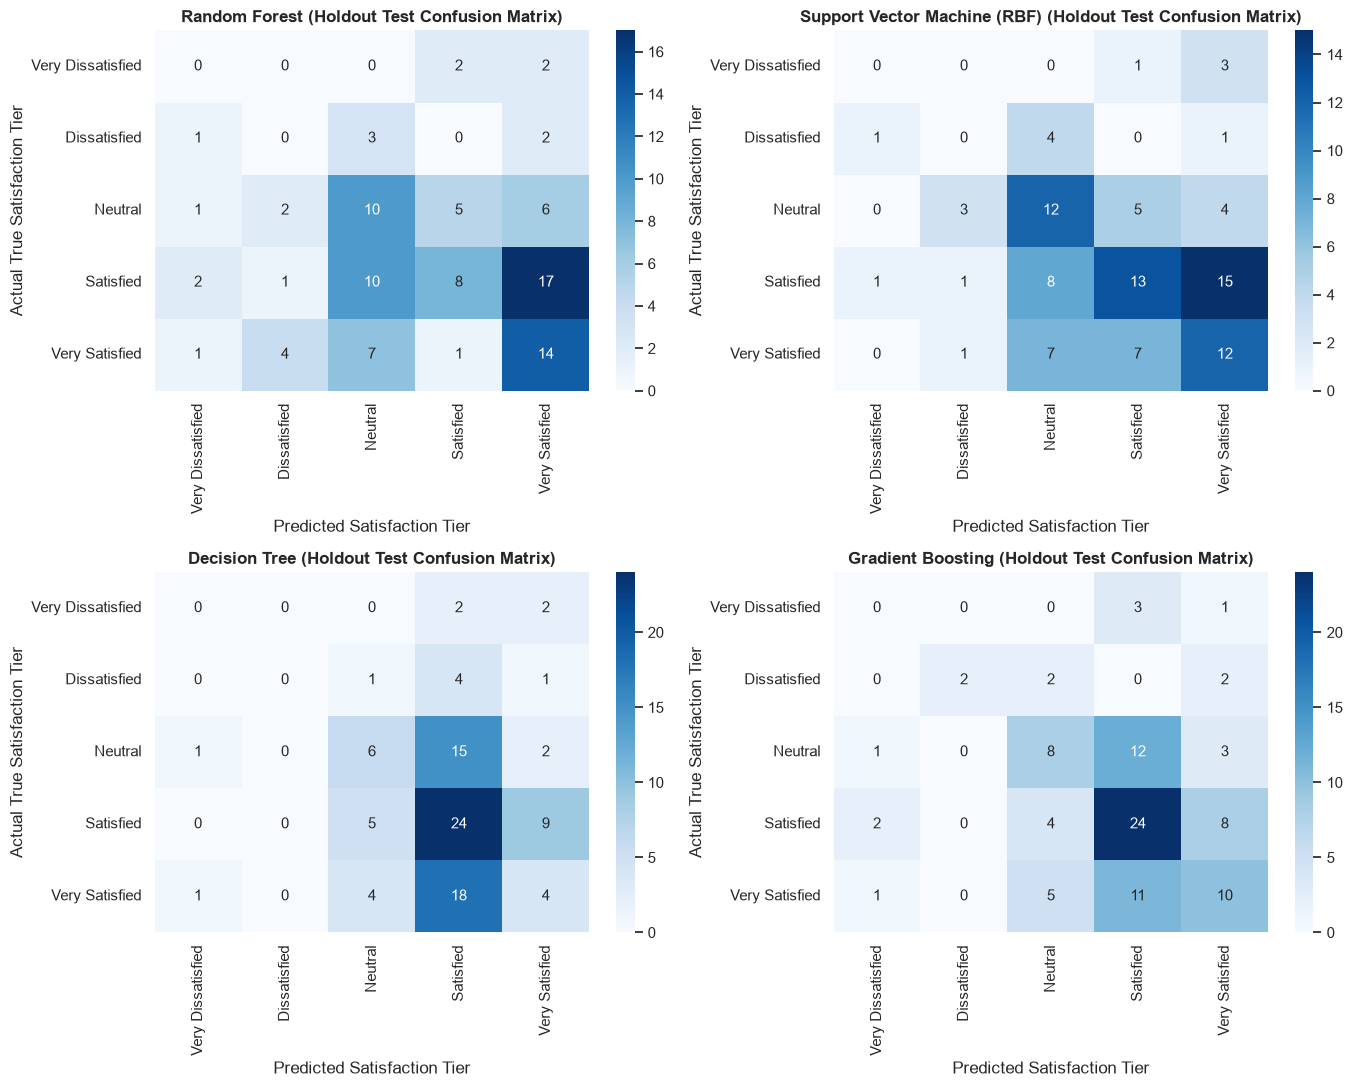

In [33]:
# 1. Bar Plot Comparison of Test Accuracy and Macro F1
plot_df = benchmark_df.copy()
plot_df['Test Accuracy'] = plot_df['_raw_test_acc']
plot_df['Test Macro F1'] = plot_df['_raw_test_f1']

fig, ax = plt.subplots(figsize=(13, 6))
x_idx = np.arange(len(plot_df))
bar_width = 0.35

rects1 = ax.bar(x_idx - bar_width/2, plot_df['Test Accuracy'], bar_width, label='Test Accuracy', color='#3498db')
rects2 = ax.bar(x_idx + bar_width/2, plot_df['Test Macro F1'], bar_width, label='Test Macro F1-Score', color='#2ecc71')

ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('9-Model Supervised Benchmark: Test Accuracy vs Macro F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x_idx)
ax.set_xticklabels(plot_df['Model Name'], rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

# 2. 5x5 Confusion Matrices for Top 4 Models
top_4_models = ['Random Forest', 'Support Vector Machine (RBF)', 'Decision Tree', 'Gradient Boosting']
labels_order = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, m_name in enumerate(top_4_models):
    pipe = trained_models[m_name]
    preds = pipe.predict(X_test)
    
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order, ax=axes[idx])
    axes[idx].set_title(f'{m_name} (Holdout Test Confusion Matrix)', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Predicted Satisfaction Tier')
    axes[idx].set_ylabel('Actual True Satisfaction Tier')

plt.tight_layout()
plt.show()

## 10. Multi-Class One-vs-Rest (OvR) ROC Curves & Macro AUC Diagnostics
We compute receiver operating characteristic curves for each of the five satisfaction classes and compute the macro-averaged AUC score for the champion model (Random Forest).

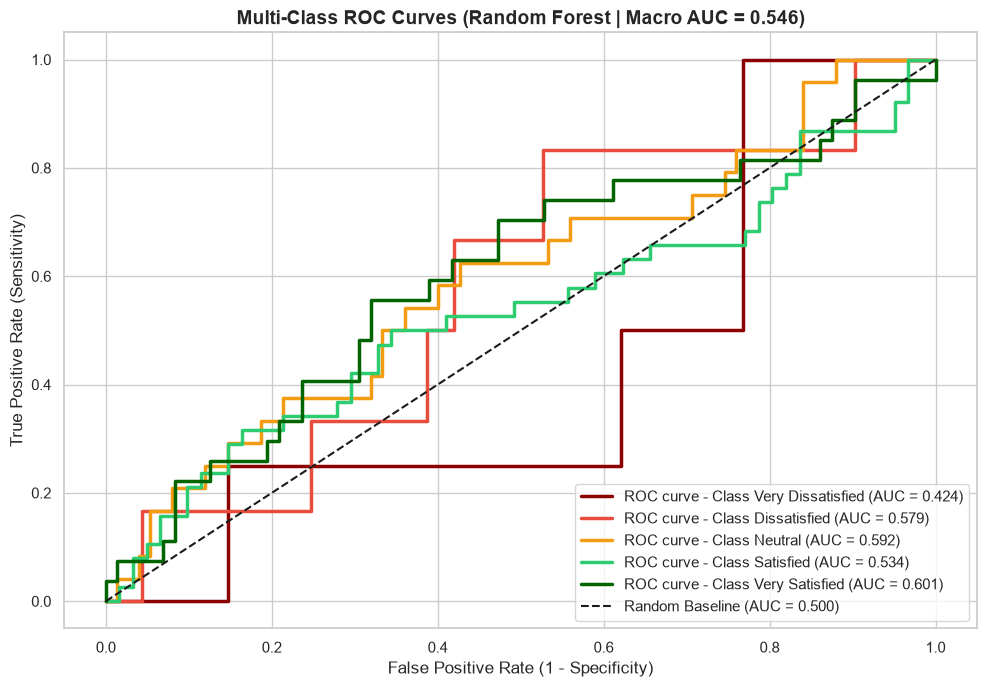

In [34]:
# Binarize holdout targets for Multi-Class OvR ROC
roc_classes = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']
y_test_bin = label_binarize(y_test, classes=roc_classes)
n_classes = 5

best_model_name = 'Random Forest'
best_pipe = trained_models[best_model_name]

if hasattr(best_pipe, "predict_proba"):
    y_score_raw = best_pipe.predict_proba(X_test)
    model_classes = list(best_pipe.named_steps['classifier'].classes_)
    class_indices = [model_classes.index(label) for label in roc_classes]
    y_score = y_score_raw[:, class_indices]
    
    fpr, tpr, roc_auc = dict(), dict(), dict()
    colors = ['#8b0000', '#e74c3c', '#f39c12', '#2ecc71', '#006400']
    classes = roc_classes
    
    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2.5,
                 label=f'ROC curve - Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Compute Macro Average AUC
    macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline (AUC = 0.500)')
    plt.title(f'Multi-Class ROC Curves ({best_model_name} | Macro AUC = {macro_auc:.3f})', fontsize=14, fontweight='bold')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.show()

## 11. Feature Importance Diagnostics (Random Forest Gini Importance)
We extract Gini feature importances to identify the key preparatory, academic, and occupational factors driving graduate career satisfaction.

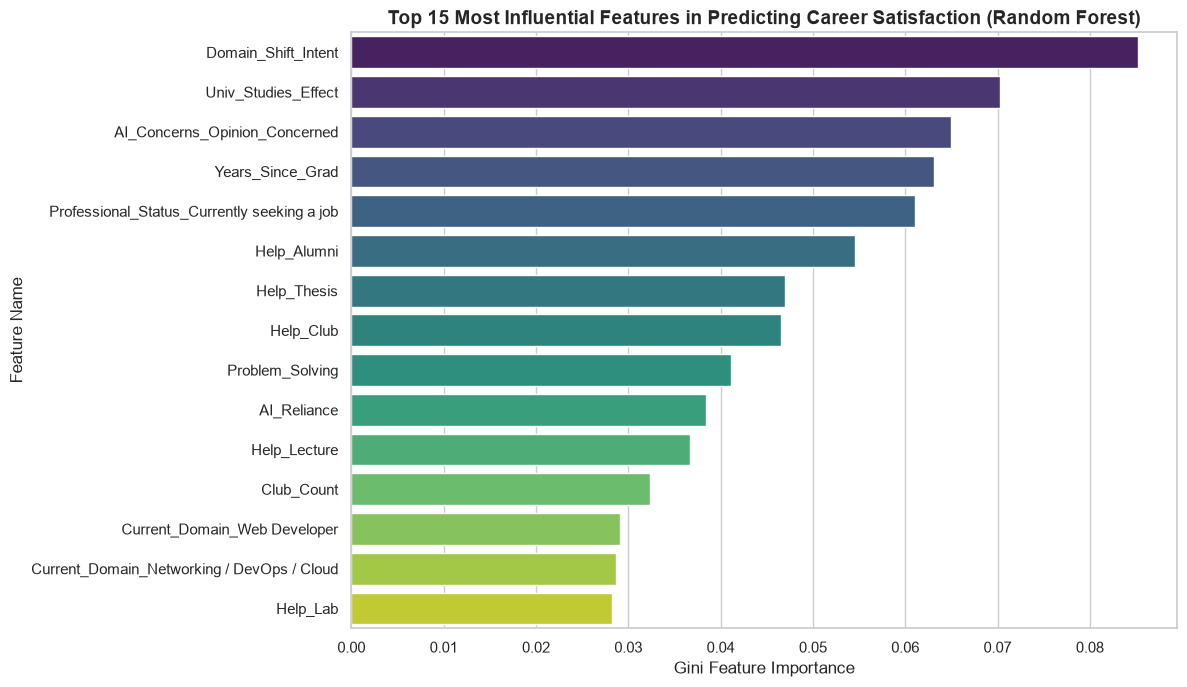

--- Top 10 Most Influential Features Table ---


,Feature Name,Importance Score
0,Domain_Shift_Intent,0.085179
1,Univ_Studies_Effect,0.070233
2,AI_Concerns_Opinion_Concerned,0.064934
3,Years_Since_Grad,0.063091
4,Professional_Status_Currently seeking a job,0.061046
5,Help_Alumni,0.054605
6,Help_Thesis,0.046987
7,Help_Club,0.046568
8,Problem_Solving,0.041099
9,AI_Reliance,0.038391


In [35]:
rf_model = trained_models['Random Forest'].named_steps['classifier']
ohe_feature_names = trained_models['Random Forest'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + ohe_feature_names

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature Name': all_feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=feat_imp_df.head(15), x='Importance Score', y='Feature Name', palette='viridis')
plt.title('Top 15 Most Influential Features in Predicting Career Satisfaction (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Gini Feature Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("--- Top 10 Most Influential Features Table ---")
display(feat_imp_df.head(10))

## 12. Export Clean Preprocessed Datasets for WEKA Replication
We export the final clean 5-class dataset to `.csv` and `.arff` format for replication in the WEKA GUI.

In [36]:
export_df = X.copy()
export_df['Career_Satisfaction'] = y.values

# Save clean CSV
csv_filename = 'career_satisfaction_5class_processed.csv'
export_df.to_csv(csv_filename, index=False)
print(f"Saved clean preprocessed CSV: {csv_filename} ({len(export_df)} rows, {len(export_df.columns)} columns)")

# Generate WEKA ARFF File with exact nominal quoting
def export_arff(df_in, target_col_name, filename):
    nominal_cols = ['Professional_Status', 'Current_Domain', 'AI_Concerns_Opinion', target_col_name]
    lines = []
    lines.append("@relation career_satisfaction_5class_classification\n")
    
    for col in df_in.columns:
        if col == target_col_name:
            lines.append(f"@attribute {col} {{'Very Dissatisfied', Dissatisfied, Neutral, Satisfied, 'Very Satisfied'}}")
        elif col in nominal_cols or df_in[col].dtype == 'object':
            uvals = sorted(list(df_in[col].dropna().unique()))
            formatted_vals = []
            for v in uvals:
                cleaned_v = str(v).replace("'", "").replace('"', '').strip()
                if any(char in cleaned_v for char in [' ', '/', '&', '-', '(', ')']):
                    formatted_vals.append(f"'{cleaned_v}'")
                else:
                    formatted_vals.append(cleaned_v)
            vals_str = "{" + ", ".join(formatted_vals) + "}"
            lines.append(f"@attribute {col} {vals_str}")
        else:
            lines.append(f"@attribute {col} numeric")
            
    lines.append("\n@data")
    for _, row in df_in.iterrows():
        row_strs = []
        for col in df_in.columns:
            val = row[col]
            if col in nominal_cols or df_in[col].dtype == 'object':
                cleaned_val = str(val).replace("'", "").replace('"', '').strip()
                if any(char in cleaned_val for char in [' ', '/', '&', '-', '(', ')']):
                    row_strs.append(f"'{cleaned_val}'")
                else:
                    row_strs.append(cleaned_val)
            else:
                if pd.isna(val):
                    row_strs.append("?")
                elif isinstance(val, (int, float, np.integer, np.floating)) and float(val).is_integer():
                    row_strs.append(str(int(val)))
                else:
                    row_strs.append(f"{float(val):.4f}")
        lines.append(",".join(row_strs))
        
    with open(filename, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines) + "\n")
    print(f"Saved WEKA ARFF file: {filename}")

arff_filename = 'career_satisfaction_5class_weka.arff'
export_arff(export_df, 'Career_Satisfaction', arff_filename)

Saved clean preprocessed CSV: career_satisfaction_5class_processed.csv (492 rows, 21 columns)
Saved WEKA ARFF file: career_satisfaction_5class_weka.arff
